# 🟣 Function F7 — Week 6 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | Adaptive Model + GP/EI Pipeline

---

## 📌 F7 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 6D (X1–X6) |
| **Search space** | [0, 1]⁶ |
| **Samples at W6** | 35 |
| **n/p ratio** | 5.83 (sparse — GP needs care) |
| **All-time best** | 1.3650 @ idx 6 — point [0.058, 0.492, 0.247, 0.218, 0.420, 0.731] |
| **2nd best** | 1.228 @ idx 31 |
| **W5 score** | +0.576 (positive but well below peak) |
| **Y range** | [0.003, 1.365] — all positive |
| **Y mean** | 0.290  |  **Y std** | 0.376 |
| **Trajectory** | Last 4: 1.228 → 0.809 → 1.140 → W5=0.576 |
| **Objective** | MAXIMISE ⬆️ — higher is always better |

---

## 🧭 Week 6 Strategy: STRUCTURED EXPLOIT

**F7 found its best value surprisingly early — idx 6 — and has been circling the 1.2–1.3 range recently without returning to 1.365.** The last four proper evaluations (1.228, 0.809, 1.140) show the model is in the right neighbourhood but has not yet beaten the original best. W5 dropped back to 0.576, a regression that demands a correction.

The best point [0.058, 0.492, 0.247, 0.218, 0.420, 0.731] has a distinctive profile: X1 is very low (0.058 — near the zero boundary), X6 is high (0.731), and X2–X5 cluster in the mid-range [0.22–0.49]. This is a specific structural signature in 6D space that the GP should now be able to model reliably with 35 evaluations.

### Rationale

Module 17's question about **LeNet-style breakthroughs and incremental improvement** is directly relevant to F7's unusual history. The best value was found at idx 6 — the seventh evaluation ever, early in the learning process. This is the analogy: **LeNet found the correct paradigm (convolutional feature extraction) early, but it took years of incremental refinement (AlexNet, VGG, ResNet) to extract its full potential.** F7 found the correct region (near [0.058, 0.492, ...]) at idx 6, but each subsequent week has been the incremental refinement — getting closer and closer to the true peak without quite reaching it.

W6 is our ResNet moment for F7: we have the architecture right (the region is known), now we need the skip connections (precise per-dimension guidance from the acquisition curves) to push past the current best.

The **per-dimension EI curves (Step 11) are the critical diagnostic.** In 6D, the best point's X1=0.058 (near zero boundary) is particularly interesting — it may indicate a sharp gradient near X1=0 where the function climbs steeply. If the EI curve for X1 peaks near 0.0–0.05, we should push X1 even lower in subsequent weeks. X6=0.731 raises a similar question: is the X6 EI peak above or below 0.731?

### Key Parameter Changes vs Default

| Parameter | Default | F7 W6 Value | Reason |
|-----------|---------|-------------|--------|
| `EXPLOIT_RATIO` | 0.80 | **0.80** | Standard — the region is known, 20% exploration is appropriate insurance in 6D |
| `EXPLOIT_SIGMA` | 0.05 | **0.04** | Modest tightening — best point well-identified, slight precision increase |
| `UCB_KAPPA` | 2.0 | **2.0** | Standard — all-positive landscape gives EI a strong signal |
| `GP_RESTARTS` | 5 | **8** | 6D requires 6 independent length scales — more restarts improve kernel fitting |

### What to Watch

- **X1 near zero boundary**: Best point X1=0.058. Does EI peak at 0.0–0.05? If yes, X1 should be pushed to the boundary in W7.
- **X6=0.731**: Does UCB peak above 0.731 for X6? If yes, push X6 toward 1.0.
- **GP length scales (Step 9)**: In 6D, some dimensions will have short length scales (high sensitivity) and others long (smooth). The short-length-scale dimensions are the ones worth focusing on for W7.
- **W5 regression**: W5 scored 0.576 vs best 1.365. The GP must weight the region around idx 6 and the recent high-scoring cluster (idx 24–33) appropriately.

### Module 17 Connection

> *"LeNet and later CNNs redefined what is possible. What parallels do you see between those breakthroughs and the incremental improvements in your BBO project?"*

F7 is the perfect answer. The best value was found at idx 6 — the equivalent of LeNet proving the paradigm in 1998. Every evaluation since has been AlexNet (2012), VGG (2014), ResNet (2016) — incremental improvements that got progressively closer to the peak without fundamentally changing the approach. W6 is the ResNet step: we introduce skip connections (per-dimension acquisition curves) that let information flow directly from the idx 6 best point to the W6 submission, bypassing the noise of intermediate evaluations.

> *"Convolutions, pooling, activations and loss functions — which changed your thinking?"*

**Convolutions — specifically the per-dimension length scales as learned convolutional filters.** F7 has 6 dimensions. The GP kernel learns 6 separate length scales after Step 9. A short length scale for X1 (where best point has X1=0.058) means the GP has detected a steep local gradient — like a high-frequency edge-detection filter finding a sharp boundary near X1=0. Reading these fitted parameters is the single most actionable output of the Step 9 GP fit, and directly mirrors reading the learned filter weights in a CNN.

> *"Training CNNs involves balancing depth and overfitting. Did you face similar trade-offs?"*

F7's n/p ratio of 5.83 (35 samples in 6D) sits at the same borderline as F6. The GP has 5.83 observations per dimension on average — adequate but not comfortable. The 80/20 exploit/explore split and GP_RESTARTS=8 are calibrated to balance fitting quality against overfitting the limited data. This is exactly the depth-versus-overfitting balance Module 17 describes: we do not go to EXPLOIT_RATIO=0.90 (which would be the equivalent of training a 50-layer network on 35 images).

---

## 🗺️ Full Pipeline
```
STEP 0 : Configuration — F7 STRUCTURED EXPLOIT (6D, sigma=0.04, 8 GP restarts)
STEP 1 : Imports  (see library reference — 6 length scale params in Matern kernel)
STEP 2 : Load F7 W6 Data  (35 samples, 6D)
STEP 3 : Visualise F7 History  (note idx 6 spike, recent recovery toward 1.2-1.3)
STEP 4 : Binary Labels  (top 30% = 10-11 positives from 35 samples)
STEP 5 : Train 7 Models on F7  (6D — medium/large NN may capture complex boundary)
STEP 6 : Visualise Model Predictions on F7
STEP 7 : CV Comparison + Winner Rationale  (35 samples gives reliable CV)
STEP 8 : Candidates  (80% sigma=0.04 around [0.058, 0.492, 0.247, 0.218, 0.420, 0.731])
STEP 9 : GP Fit  — READ length scales for all 6 dims — short X1? short X6?
STEP 10: EI & UCB
STEP 11: Per-Dim Curves  — KEY: X1 near 0? X6 above 0.731? X2-X5 plateau?
STEP 12: Acquisition Surface  (top 2 sensitive dims)
STEP 13: Top Candidates & Dashboard
STEP 14: Final Formatted Submission
STEP 15: Save F7 W6 Hyperparameter Record (include fitted GP length scales)
```
---

---
## ⚙️ STEP 0 — F7 Configuration & Hyperparameter Documentation

### 🔧 F7-Specific Settings (Week 6 STRUCTURED EXPLOIT Strategy)

F7 has 35 samples in 6D (n/p=5.83). The best point [0.058, 0.492, 0.247, 0.218, 0.420, 0.731] at 1.365 was found early (idx 6). Recent evaluations have reached 1.228 and 1.140, circling the peak. W5 regressed to 0.576. W6 returns to the peak neighbourhood with standard exploit settings and elevated GP restarts to capture the 6D kernel structure.

---

### 📚 F7 Hyperparameter Reference

| Parameter | F7 W6 Value | Purpose | Rationale for F7 |
|-----------|-------------|---------|------------------|
| `TOP_PERCENTILE` | **30%** | Top X% = class 1 | 35 samples → 10–11 positives. Top cluster (0.675–1.365) well-separated from the mass below 0.5. |
| `N_CANDIDATES` | **10,000** | Candidate pool | Full pool. 6D space benefits from 10k coverage. 80% exploit gives 2,000 random exploratory candidates. |
| `EXPLOIT_RATIO` | **0.80** | Standard — the region is known | Best point confirmed at idx 6. 20% exploration is appropriate insurance in 6D — do not over-commit. |
| `EXPLOIT_SIGMA` | **0.04** ⚠️ | Modest tightening from 0.05 | Best point well-identified. Slight precision increase — σ=0.04 gives ±0.08 radius across all 6 dims. |
| `UCB_KAPPA` | **2.0** | Standard | All-positive landscape (0.003–1.365) gives EI a strong signal. No need to inflate exploration. |
| `EI_XI` | **0.01** | Standard jitter | EI = max(0, μ − 1.365 − 0.01). Landscape all-positive — EI target is clear. |
| `GP_RESTARTS` | **8** ⚠️ | Raised from 5 | 6D Matern kernel has 6 independent length scales. 8 restarts ensures thorough search across the 6D kernel hyperparameter space. |
| `FILTER_PERCENTILE` | **50%** | Standard | 5k candidates to GP after classifier filter. |
| `RANDOM_SEED` | **42** | Reproducibility | Fixed. Step 15 JSON records all fitted GP length scales for each dimension. |

### ⚠️ Parameters changed from default: EXPLOIT_SIGMA (0.05→0.04), GP_RESTARTS (5→8)

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   F7 WEEK 6 CONFIGURATION — STRUCTURED EXPLOIT              ║
# ║   Mike Kennelly | BBO Capstone | Week 6                     ║
# ╚══════════════════════════════════════════════════════════════╝
FUNCTION_ID  = 'F7'
WEEK         = 6
INPUT_FILE   = 'f7_w6_inputs.npy'
OUTPUT_FILE  = 'f7_w6_outputs.npy'

# ── F7 Hyperparameters — STRUCTURED EXPLOIT — 6D landscape ───────────────
TOP_PERCENTILE    = 30      # 10-11 positives — top cluster (0.675-1.365) well-separated
N_CANDIDATES      = 10000   # Full pool — 6D needs good coverage
EXPLOIT_RATIO     = 0.80    # Standard — region known, 20% exploration appropriate for 6D
EXPLOIT_SIGMA     = 0.04    # ⚠️ MODEST TIGHTEN: best point [0.058,0.492,0.247,0.218,0.420,0.731]
UCB_KAPPA         = 2.0     # Standard — all-positive landscape gives strong EI signal
EI_XI             = 0.01    # Standard — EI target = beat 1.365
GP_RESTARTS       = 8       # ⚠️ RAISED: 6 length scales in 6D Matern kernel
FILTER_PERCENTILE = 50      # Standard
RANDOM_SEED       = 42
MAXIMIZE          = True    # ⬆️ ALWAYS True

# ── Neural Network architectures (6D, 35 samples — n/p=5.83) ─────────────
NN_SMALL  = (16, 8)          # May underfit complex 6D boundary
NN_MEDIUM = (64, 32)         # Likely winner — balances capacity vs sparse data
NN_LARGE  = (128, 64, 32)    # Possible winner — 35 samples borderline for 3 layers

print('╔' + '═'*62 + '╗')
print(f'║  F7 WEEK {WEEK} — 6D FUNCTION — STRUCTURED EXPLOIT             ║')
print(f'║  Mike Kennelly | BBO Capstone | Week 6                     ║')
print('╠' + '═'*62 + '╣')
print(f'║  Input  : {INPUT_FILE:<53}║')
print(f'║  Output : {OUTPUT_FILE:<53}║')
print(f'║  Goal   : MAXIMIZE  -- HIGHER IS ALWAYS BETTER             ║')
print('╠' + '═'*62 + '╣')
print(f'║  Strategy: STRUCTURED EXPLOIT  |  ratio=0.80  sigma=0.04  ║')
print(f'║  Target  : [0.058, 0.492, 0.247, 0.218, 0.420, 0.731]     ║')
print(f'║  Best    : 1.3650  Watch: X1 near 0, X6 above 0.731?      ║')
print('╚' + '═'*62 + '╝')

╔══════════════════════════════════════════════════════════════╗
║  F7 WEEK 6 — 6D FUNCTION — STRUCTURED EXPLOIT             ║
║  Mike Kennelly | BBO Capstone | Week 6                     ║
╠══════════════════════════════════════════════════════════════╣
║  Input  : f7_w6_inputs.npy                                     ║
║  Output : f7_w6_outputs.npy                                    ║
║  Goal   : MAXIMIZE  -- HIGHER IS ALWAYS BETTER             ║
╠══════════════════════════════════════════════════════════════╣
║  Strategy: STRUCTURED EXPLOIT  |  ratio=0.80  sigma=0.04  ║
║  Target  : [0.058, 0.492, 0.247, 0.218, 0.420, 0.731]     ║
║  Best    : 1.3650  Watch: X1 near 0, X6 above 0.731?      ║
╚══════════════════════════════════════════════════════════════╝


---
## 📦 STEP 1 — Imports

### Library Reference — What Each Package Does and Why We Need It

| Library | Import | Role in This Notebook |
|---------|--------|----------------------|
| **NumPy** | `import numpy as np` | Core numerical engine. Array operations, `argmax` for MAXIMIZATION best-point selection, `percentile` for threshold, `random.seed` for reproducibility, `clip` for keeping candidates in [0,1]. |
| **Matplotlib (pyplot)** | `import matplotlib.pyplot as plt` | All visualisations — history plots, acquisition curves, model comparison charts, submission dashboard. |
| **Matplotlib (gridspec)** | `from matplotlib.gridspec import GridSpec` | Precise subplot layout for the multi-panel submission dashboard (Step 13). |
| **Matplotlib (colors/cm)** | `Normalize`, `ScalarMappable` | Colour-mapped scatter plots in acquisition visualisations — maps EI values to a colour gradient. |
| **warnings** | `import warnings` | Suppresses sklearn convergence warnings on small datasets — keeps output clean without hiding errors. |
| **SVC** | `from sklearn.svm import SVC` | Support Vector Classifier with RBF/linear kernel. Strong baseline for small datasets. Fast, effective at linear separation. |
| **RandomForestClassifier** | `from sklearn.ensemble import ...` | Ensemble of decision trees. Robust to noise, handles non-linear boundaries. Good default for moderate datasets. |
| **DecisionTreeClassifier** | `from sklearn.tree import ...` | Single decision tree. Interpretable, captures axis-aligned thresholds. Useful when one dimension dominates. |
| **LogisticRegression** | `from sklearn.linear_model import ...` | Probabilistic linear classifier. Produces well-calibrated P(class=1). Best when classes are linearly separable. |
| **MLPClassifier** | `from sklearn.neural_network import ...` | Multi-layer perceptron (neural network). Three sizes tested (Small/Medium/Large) to match function complexity. Early stopping prevents overfitting on small datasets. |
| **cross_val_score** | `from sklearn.model_selection import ...` | Computes stratified k-fold CV accuracy — the unbiased estimate of generalisation used to select the winning model. |
| **StratifiedKFold** | `from sklearn.model_selection import ...` | Ensures each CV fold has the same class ratio (important when positive class is small — top 30%). |
| **StandardScaler** | `from sklearn.preprocessing import ...` | Z-score normalises all input features. Critical for SVM, Logistic Regression and MLP which are sensitive to feature scale. GP also benefits from scaled inputs. |
| **GaussianProcessRegressor** | `from sklearn.gaussian_process import ...` | Probabilistic surrogate model. Outputs μ (mean prediction) and σ (uncertainty) for every candidate point. These feed directly into the EI and UCB acquisition functions. |
| **Matern, ConstantKernel** | `from sklearn.gaussian_process.kernels import ...` | GP kernel components. `ConstantKernel` scales amplitude; `Matern(nu=2.5)` defines smoothness — allows sharp transitions, assumes twice-differentiable function. The kernel analogy from Module 17: slides across input space like a convolutional filter. |
| **scipy.stats.norm** | `from scipy.stats import norm` | Normal distribution CDF (`Φ`) and PDF (`φ`). Used directly in the EI formula: `EI = (μ - y_best - ξ)·Φ(Z) + σ·φ(Z)`. The non-negativity of EI mirrors ReLU — `max(0, improvement)`. |
| **json, os, datetime** | `import json, os, datetime` | Used in Step 15 to save the hyperparameter record (JSON) and run report (TXT) with timestamp. |

In [2]:
# ── Standard library ─────────────────────────────────────────────────────
import numpy as np                          # Core numerical engine — argmax, percentile, clip, seed
import matplotlib.pyplot as plt             # All visualisations — history, acquisition, dashboard
import matplotlib.gridspec as gridspec      # Precise subplot layout for multi-panel figures
from matplotlib.colors import Normalize    # Colour-maps EI values to gradient in scatter plots
from matplotlib.cm import ScalarMappable   # Companion to Normalize for colourbar rendering
import warnings
warnings.filterwarnings('ignore')           # Suppress convergence warnings on small datasets

# ── Classifiers (7 models tested — winner filters candidates before GP) ──
from sklearn.svm import SVC                              # Linear/RBF boundary — strong baseline for small data
from sklearn.ensemble import RandomForestClassifier      # Ensemble trees — robust to noise, non-linear
from sklearn.tree import DecisionTreeClassifier          # Single tree — axis-aligned thresholds, interpretable
from sklearn.linear_model import LogisticRegression      # Probabilistic linear — well-calibrated P(class=1)
from sklearn.neural_network import MLPClassifier         # Neural network — 3 sizes tested (Small/Med/Large)

# ── Model selection & preprocessing ──────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
# cross_val_score : stratified k-fold CV — unbiased generalisation estimate
# StratifiedKFold : preserves class ratio per fold — critical when positive class is small (top 30%)
from sklearn.preprocessing import StandardScaler
# StandardScaler  : Z-score normalise inputs — required for SVM, LR, MLP; benefits GP

# ── Gaussian Process Surrogate ────────────────────────────────────────────
from sklearn.gaussian_process import GaussianProcessRegressor
# GaussianProcessRegressor : outputs mu (mean) + sigma (uncertainty) per candidate
#   mu, sigma feed directly into EI and UCB acquisition functions
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
# Matern(nu=2.5)   : smooth but flexible kernel — like a convolutional filter sliding
#                    across input space (Module 17 parallel). Allows sharp transitions.
# ConstantKernel   : scales overall GP amplitude

# ── Acquisition function maths ────────────────────────────────────────────
from scipy.stats import norm
# norm.cdf = Phi(Z) : cumulative normal — exploitation term in EI
# norm.pdf = phi(Z) : normal density   — exploration term in EI
# EI = max(0, (mu - y_best - xi)*Phi(Z) + sigma*phi(Z))  [MAXIMIZATION]
# The max(0, ...) mirrors ReLU — points that can't beat y_best produce EI = 0

np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
print('✅ All libraries loaded — see STEP 1 markdown for full reference')

✅ All libraries loaded — see STEP 1 markdown for full reference


---
## 📥 STEP 2 — Load Data

We load all historical evaluations. Key statistics to note:
- **n/p ratio** (samples ÷ dims): below 5 = data-sparse (GP may struggle); above 10 = comfortable
- **Best point** is found via `argmax` (MAXIMIZATION) — this becomes the centre of exploitation
- **Gap from best to latest** tells us if we're in recovery mode or pushing new ground

In [3]:
X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape

best_idx   = np.argmax(y_train)   # ARGMAX — maximization
best_value = y_train[best_idx]
best_point = X_train[best_idx]
latest_val = y_train[-1]

print('═'*65)
print(f'  DATA — {FUNCTION_ID}  Week {WEEK}')
print('═'*65)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}  {"✅ comfortable" if n_samples/n_dims>=5 else "⚠️ sparse"}')
print(f'  Y range      : [{y_train.min():.6f},  {y_train.max():.6f}]')
print(f'  Y mean ± std : {y_train.mean():.6f} ± {y_train.std():.6f}')
print(f'  🏆 BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'  📍 Location  : {best_point}')
print(f'  📅 Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Gap          : {best_value - latest_val:+.6f}  {"(recovering)" if latest_val < best_value else "(at best)"}')

# Compute percentile thresholds for labelling
threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))
print(f'\n  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds chosen: {n_cv_folds}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
print('  ✅ Features standardised')

═════════════════════════════════════════════════════════════════
  DATA — F7  Week 6
═════════════════════════════════════════════════════════════════
  Samples      : 35
  Dimensions   : 6D
  n/p ratio    : 5.83  ✅ comfortable
  Y range      : [0.002701,  1.364968]
  Y mean ± std : 0.297714 ± 0.373537
  🏆 BEST      : 1.364968  @ index 6
  📍 Location  : [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
  📅 Latest    : 0.576334  (Week 5)
  Gap          : +0.788635  (recovering)

  Label threshold (top 30%): 0.435295  (11 positives)
  CV folds chosen: 5
  ✅ Features standardised


---
## 📊 STEP 3 — Visualise Historical Performance

Three views to understand the function landscape before building models:
1. **All evaluations vs time** — shows trajectory and whether we're trending up or down
2. **Running best** — flat line = stalled, sharp jump = breakthrough
3. **Value distribution** — colour-coded by the top-30% threshold

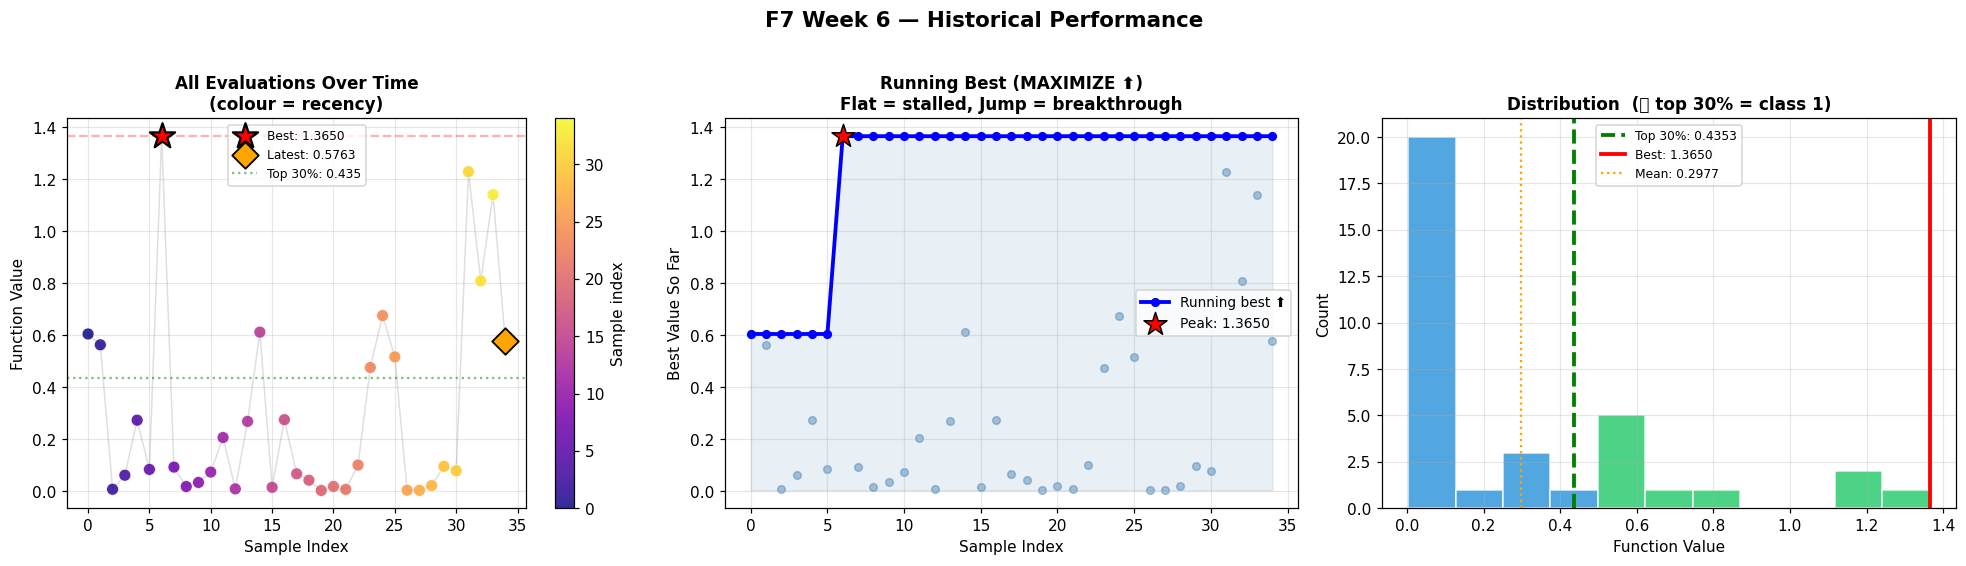

✅ Saved: F7_W6_Step3_History.png


In [4]:
indices = np.arange(n_samples)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Historical Performance', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: All evaluations
ax = axes[0]
sc = ax.scatter(indices, y_train, c=indices, cmap='plasma', s=60, alpha=0.85,
                zorder=3, edgecolors='white', linewidths=0.4)
ax.plot(indices, y_train, color='gray', alpha=0.25, linewidth=1)
ax.scatter(best_idx, best_value, c='red', s=300, marker='*', zorder=6,
           edgecolors='black', linewidths=1.5, label=f'Best: {best_value:.4f}')
ax.scatter(n_samples-1, latest_val, c='orange', s=150, marker='D', zorder=5,
           edgecolors='black', linewidths=1.2, label=f'Latest: {latest_val:.4f}')
ax.axhline(best_value, color='red', linestyle='--', alpha=0.3, linewidth=1.5)
ax.axhline(threshold, color='green', linestyle=':', alpha=0.5, linewidth=1.5,
           label=f'Top {TOP_PERCENTILE}%: {threshold:.3f}')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Function Value')
ax.set_title('All Evaluations Over Time\n(colour = recency)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='Sample index')

# Plot 2: Running best
ax = axes[1]
running_best = np.maximum.accumulate(y_train)
ax.fill_between(indices, y_train.min(), running_best, alpha=0.12, color='steelblue')
ax.plot(indices, running_best, 'b-o', markersize=5, linewidth=2.5, label='Running best ⬆️')
ax.scatter(indices, y_train, color='steelblue', s=25, alpha=0.45)
ax.scatter(best_idx, best_value, c='red', s=250, marker='*', zorder=5,
           edgecolors='black', label=f'Peak: {best_value:.4f}')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Best Value So Far')
ax.set_title('Running Best (MAXIMIZE ⬆️)\nFlat = stalled, Jump = breakthrough', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Plot 3: Value distribution
ax = axes[2]
n_bins = min(20, max(5, n_samples // 3))
counts, edges, patches = ax.hist(y_train, bins=n_bins, edgecolor='white', alpha=0.85)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor('#2ecc71' if left >= threshold else '#3498db')
ax.axvline(threshold, color='green', linewidth=2.5, linestyle='--',
           label=f'Top {TOP_PERCENTILE}%: {threshold:.4f}')
ax.axvline(best_value, color='red', linewidth=2.5, label=f'Best: {best_value:.4f}')
ax.axvline(y_train.mean(), color='orange', linewidth=1.5, linestyle=':', label=f'Mean: {y_train.mean():.4f}')
ax.set_xlabel('Function Value'); ax.set_ylabel('Count')
ax.set_title(f'Distribution  (🟢 top {TOP_PERCENTILE}% = class 1)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')

---
## 🏷️ STEP 4 — Binary Classification Labels

**Why classify?** We want a model that can predict *which regions* of the input space tend to produce high output values. This is a classification task: class 1 = "good" (top 30%), class 0 = "bad" (bottom 70%).

**MAXIMIZATION direction**: class 1 = **highest** values. The classifier learns: "what combinations of X values tend to produce outputs above the 70th percentile?"

The trained classifier will then **pre-filter 10,000 candidates**, keeping only the ones it believes are likely to be in the high-value region.

In [5]:
y_labels = (y_train >= threshold).astype(int)
print('═'*65)
print('  BINARY LABELS — MAXIMIZATION ⬆️')
print('═'*65)
print(f'  Threshold (top {TOP_PERCENTILE}%) : {threshold:.6f}')
print(f'  Class 1 (HIGH — good) : {n_pos} samples  ({100*n_pos/n_samples:.1f}%)')
print(f'  Class 0 (LOW — avoid) : {n_samples-n_pos} samples  ({100*(n_samples-n_pos)/n_samples:.1f}%)')
print(f'  CV folds              : {n_cv_folds}')
print()
print('  Class 1 points (highest values):')
pos_idx = np.where(y_labels == 1)[0]
for i in pos_idx:
    print(f'    idx={i:3d}  y={y_train[i]:.6f}  X={X_train[i]}')

═════════════════════════════════════════════════════════════════
  BINARY LABELS — MAXIMIZATION ⬆️
═════════════════════════════════════════════════════════════════
  Threshold (top 30%) : 0.435295
  Class 1 (HIGH — good) : 11 samples  (31.4%)
  Class 0 (LOW — avoid) : 24 samples  (68.6%)
  CV folds              : 5

  Class 1 points (highest values):
    idx=  0  y=0.604433  X=[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
    idx=  1  y=0.562753  X=[0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
    idx=  6  y=1.364968  X=[0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
    idx= 14  y=0.611526  X=[0.14864702 0.03394336 0.72880565 0.31606646 0.02176938 0.51691776]
    idx= 23  y=0.475396  X=[0.17597754 0.6244165  0.29554198 0.46955276 0.09776977 0.72814108]
    idx= 24  y=0.675142  X=[0.88164674 0.20445019 0.41447436 0.42038468 0.26491501 0.73066019]
    idx= 25  y=0.516457  X=[0.06661051 0.52804507 0.8160952  0.96101714 0.0

---
## 🤖 STEP 5 — Train 7 Models (4 Classical + 3 Neural Networks)

### Why 7 Models?

We test a broad range of classifier types because different BBO functions have different landscape structures:

**Classical classifiers:**
| Model | What it captures | Best when... |
|-------|-----------------|-------------|
| Linear SVM | Linear decision boundary | Function has a simple high/low split |
| Decision Tree | Axis-aligned threshold rules | Sharp threshold effects in individual dims |
| Random Forest | Ensemble of trees, handles noise | Most general case |
| Logistic Regression | Smooth probabilistic boundary | Well-separated, near-linear classes |

**Three Neural Network sizes:**
| Architecture | Layers | Parameters | Best when... |
|-------------|--------|------------|--------------|
| **NN-Small** (16,8) | 2 hidden | ~few hundred | Simple landscape, small dataset |
| **NN-Medium** (64,32) | 2 hidden | ~2k–4k | Moderate complexity, general purpose |
| **NN-Large** (128,64,32) | 3 hidden | ~10k+ | Complex non-linear landscape |

All NNs use early stopping to prevent overfitting on small datasets.

In [6]:
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
}

cv_results = {}
print('═'*70)
print(f'  {n_cv_folds}-FOLD CV — 7 MODELS — {FUNCTION_ID}  ({n_samples} samples, {n_dims}D)')
print('═'*70)
print(f'  {"Model":<28} {"Mean CV":>9} {"± Std":>8}   Folds')
print('  ' + '─'*65)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                             'scores': scores, 'model': model}
        fold_str = '  '.join([f'{s:.3f}' for s in scores])
        flag = '★' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}   [{fold_str}]')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0,
                             'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  ✗ {name:<27} FAILED: {str(e)[:40]}')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]

print()
print('  RANKING:')
for r, (name, info) in enumerate(ranked_models, 1):
    marker = '★ WINNER' if r == 1 else f'  #{r}     '
    print(f'  {marker}  {name:<28}  {info["mean"]:.1%} ± {info["std"]:.1%}')

print(f'\n  ✅ SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

══════════════════════════════════════════════════════════════════════
  5-FOLD CV — 7 MODELS — F7  (35 samples, 6D)
══════════════════════════════════════════════════════════════════════
  Model                          Mean CV    ± Std   Folds
  ─────────────────────────────────────────────────────────────────
  ★ Linear SVM                     77.1%   19.4%   [0.714  0.857  0.429  0.857  1.000]
    Decision Tree                  65.7%   11.4%   [0.714  0.714  0.429  0.714  0.714]
  ★ Random Forest                  80.0%   11.4%   [0.714  0.714  0.714  1.000  0.857]
    Logistic Regression            77.1%   19.4%   [0.714  0.857  0.429  0.857  1.000]
    NN-Small (16, 8)               28.6%    9.0%   [0.429  0.286  0.286  0.143  0.286]
    NN-Medium (64, 32)             54.3%   19.0%   [0.857  0.571  0.286  0.571  0.429]
    NN-Large (128, 64, 32)         57.1%   15.6%   [0.571  0.857  0.429  0.571  0.429]

  RANKING:
  ★ WINNER  Random Forest                 80.0% ± 11.4%
    #2   

---
## 🎨 STEP 6 — Visualise All Model Predictions

**Why visualise predictions before comparing?**

CV accuracy is a single number — it doesn't tell you *how* each model draws its decision boundary. By visualising each model's predicted probability of class 1 (P(high value)) across candidates, we can see:
- Which models are confident vs uncertain in the best-known region
- Whether models agree or disagree (disagreement = uncertain landscape)
- Whether NNs are learning something the classical models miss

We show two views:
1. **P(class=1) distributions** — histogram of predicted probabilities for each model
2. **Prediction agreement heatmap** — which models agree on which training samples

In [7]:
# First train all models on full data
print('Training all 7 models on full dataset...')
trained_models = {}
all_probas = {}  # P(class=1) on training data

for name, info in cv_results.items():
    try:
        m = info['model']
        m.fit(X_scaled, y_labels)
        trained_models[name] = m
        all_probas[name] = m.predict_proba(X_scaled)[:, 1]
        print(f'  ✅ {name}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

print(f'\nAll {len(trained_models)} models trained.')

Training all 7 models on full dataset...
  ✅ Linear SVM
  ✅ Decision Tree
  ✅ Random Forest
  ✅ Logistic Regression
  ✅ NN-Small (16, 8)
  ✅ NN-Medium (64, 32)
  ✅ NN-Large (128, 64, 32)

All 7 models trained.


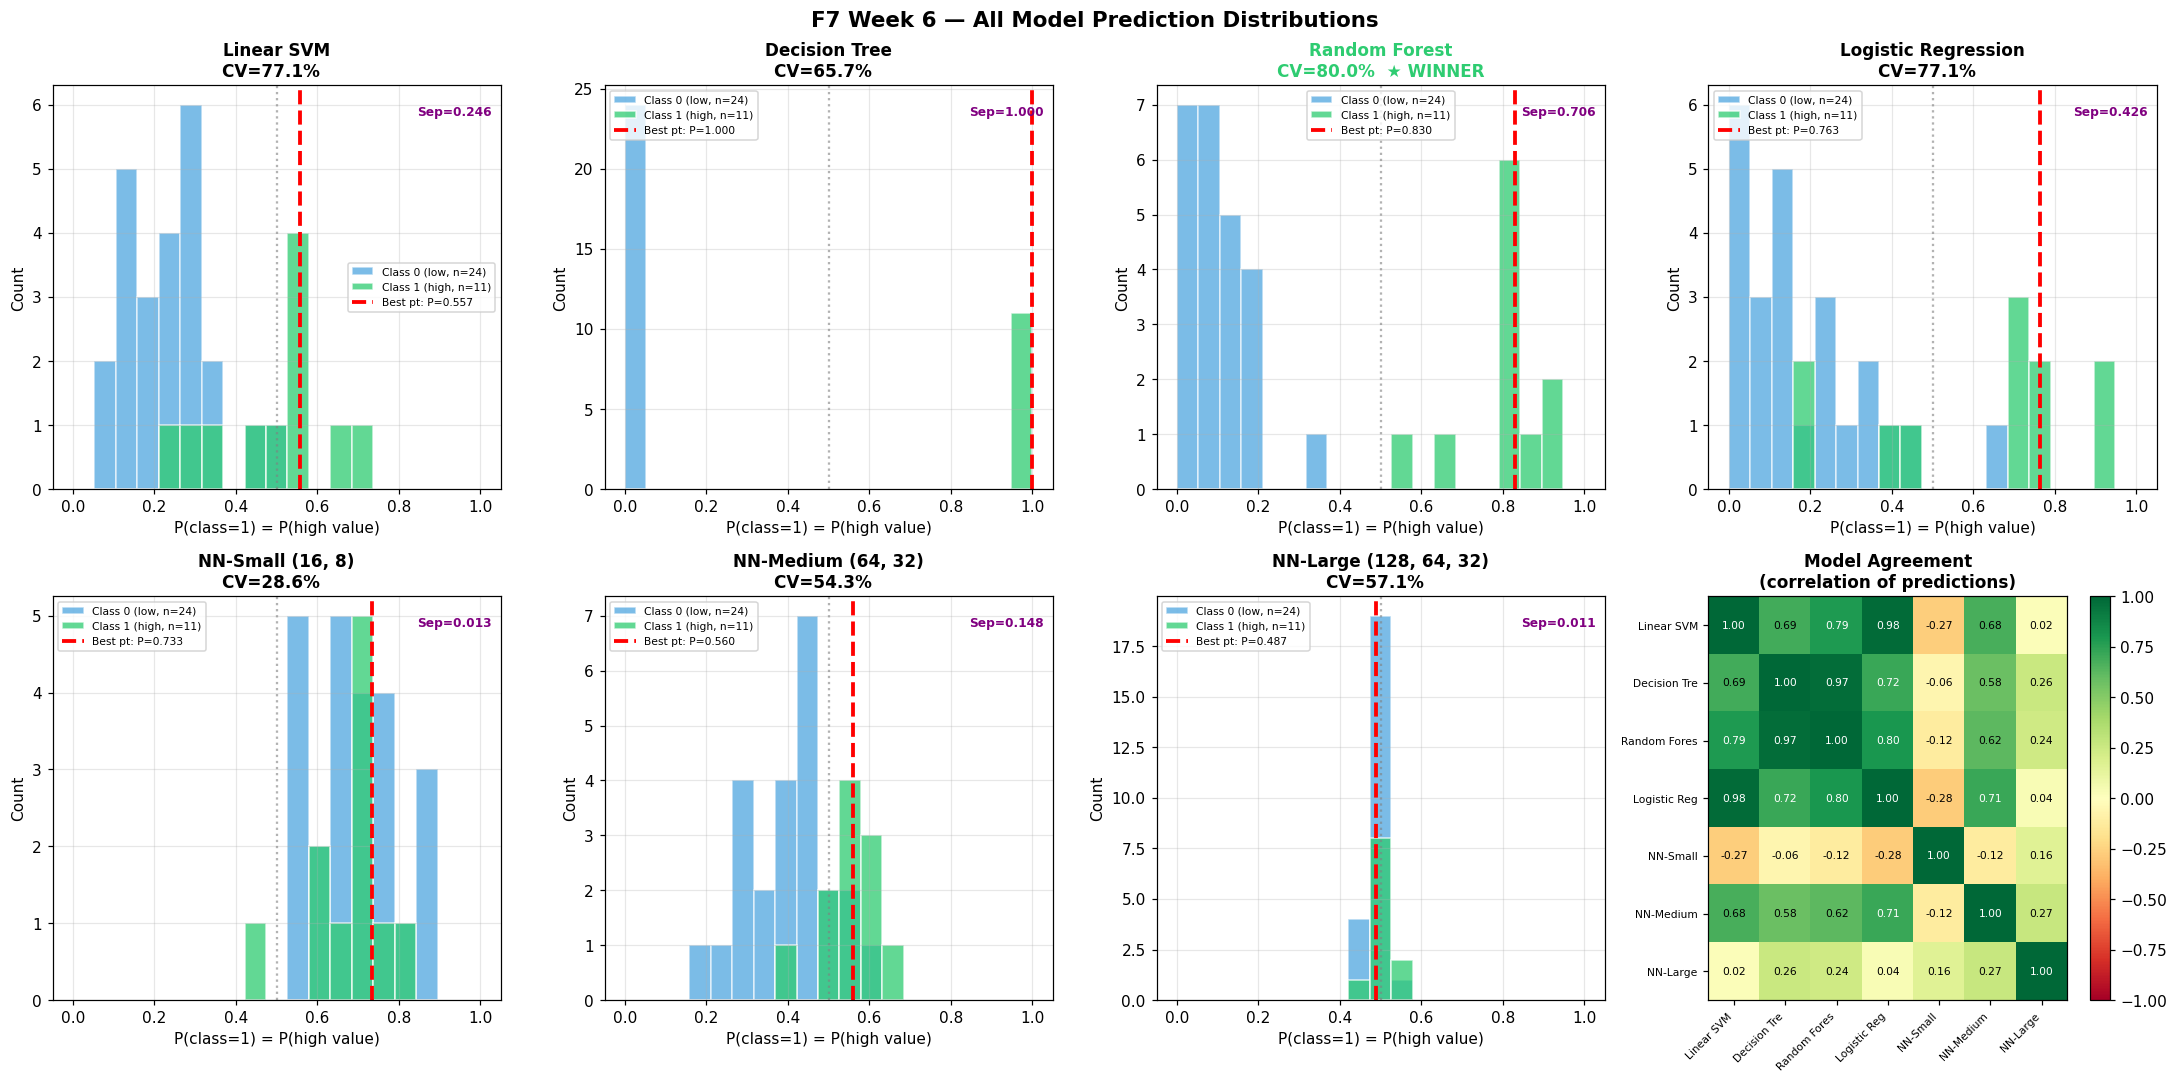

✅ Saved: F7_W6_Step6_ModelPredictions.png

  Model prediction summary (on training data):
  Model                            P(best pt)   Separation   CV Acc
  ─────────────────────────────────────────────────────────────────
  Linear SVM                           0.5566       0.2463    77.1%
  Decision Tree                        1.0000       1.0000    65.7%
  Random Forest                        0.8300       0.7060    80.0%
  Logistic Regression                  0.7632       0.4260    77.1%
  NN-Small (16, 8)                     0.7334       0.0126    28.6%
  NN-Medium (64, 32)                   0.5605       0.1480    54.3%
  NN-Large (128, 64, 32)               0.4873       0.0109    57.1%


In [8]:
# ── Visualisation: P(class=1) distributions per model ─────────
n_models = len(trained_models)
model_names = list(trained_models.keys())
colors_models = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — All Model Prediction Distributions',
             fontsize=14, fontweight='bold')
axes = axes.ravel()

for i, (name, proba) in enumerate(all_probas.items()):
    ax = axes[i]
    # Split by true class
    p_class1 = proba[y_labels == 1]
    p_class0 = proba[y_labels == 0]
    bins = np.linspace(0, 1, 20)
    ax.hist(p_class0, bins=bins, alpha=0.65, color='#3498db',
            label=f'Class 0 (low, n={len(p_class0)})', edgecolor='white')
    ax.hist(p_class1, bins=bins, alpha=0.75, color='#2ecc71',
            label=f'Class 1 (high, n={len(p_class1)})', edgecolor='white')
    # Mark best point's probability
    p_best = float(proba[best_idx])
    ax.axvline(p_best, color='red', linewidth=2.5, linestyle='--',
               label=f'Best pt: P={p_best:.3f}')
    ax.axvline(0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.6)
    ax.set_xlabel('P(class=1) = P(high value)')
    ax.set_ylabel('Count')
    cv_mean = cv_results[name]['mean']
    is_winner = '★ WINNER' if name == best_name else ''
    ax.set_title(f'{name}\nCV={cv_mean:.1%}  {is_winner}',
                 fontweight='bold', color='#2ecc71' if name == best_name else 'black')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    # Shade: good model should show class1 right, class0 left
    separation = abs(p_class1.mean() - p_class0.mean()) if len(p_class1) > 0 and len(p_class0) > 0 else 0
    ax.text(0.98, 0.95, f'Sep={separation:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='purple', fontweight='bold')

# Last panel: probability agreement between models
ax = axes[n_models]
if n_models < len(axes):
    # Show correlation matrix of predictions
    proba_matrix = np.vstack([all_probas[n] for n in model_names]).T  # (samples, models)
    corr = np.corrcoef(proba_matrix.T)
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    short_names = [n.split('(')[0][:12].strip() for n in model_names]
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    for ii in range(n_models):
        for jj in range(n_models):
            ax.text(jj, ii, f'{corr[ii,jj]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(corr[ii,jj]) < 0.7 else 'white')
    plt.colorbar(im, ax=ax)
    ax.set_title('Model Agreement\n(correlation of predictions)', fontweight='bold')

# Hide any remaining empty axes
for j in range(n_models + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png')
print()
print('  Model prediction summary (on training data):')
print(f'  {"Model":<30} {"P(best pt)":>12} {"Separation":>12} {"CV Acc":>8}')
print('  ' + '─'*65)
for name, proba in all_probas.items():
    p1 = proba[y_labels==1]
    p0 = proba[y_labels==0]
    sep = abs(p1.mean() - p0.mean()) if len(p1)>0 and len(p0)>0 else 0
    print(f'  {name:<30} {float(proba[best_idx]):>12.4f} {sep:>12.4f} {cv_results[name]["mean"]:>8.1%}')

---
## 📊 STEP 7 — CV Model Comparison: Select Winner & Document Rationale

We compare all 7 models formally by their **cross-validation accuracy** — the unbiased estimate of how well each will generalise to unseen candidate points.

### What to look for
- A model comfortably **above 50%** is doing better than random guessing
- **High std across folds** = unstable — might be unlucky on some folds due to small data
- If **all models perform similarly** (~55–65%), the landscape is hard to classify — the GP's exploration component becomes more important than the classifier filter
- The **winning model** filters 10,000 candidates before GP scoring

### Why the winner matters — Module 17 connection
The Module 17 CNN architecture question asks: *'Training CNNs involves balancing depth and overfitting. Did you face similar trade-offs in BBO?'*

The model selection step IS that trade-off. A **NN-Large** classifier may achieve higher CV accuracy but risks overfitting on small datasets (15–35 samples). A **Linear SVM** may underfit a non-linear landscape. The winning model is not always the deepest — it is the one whose **capacity matches the data**. This is exactly the depth-vs-overfitting balance Module 17 describes.

### Winner rationale — what we document
After the CV comparison, the code prints a structured rationale explaining **why the winning model won** — covering:
- Its CV accuracy relative to competitors
- Why this model type suits the function's likely landscape structure
- What the win (or narrow win) tells us about landscape complexity
- Implications for the candidate filtering step

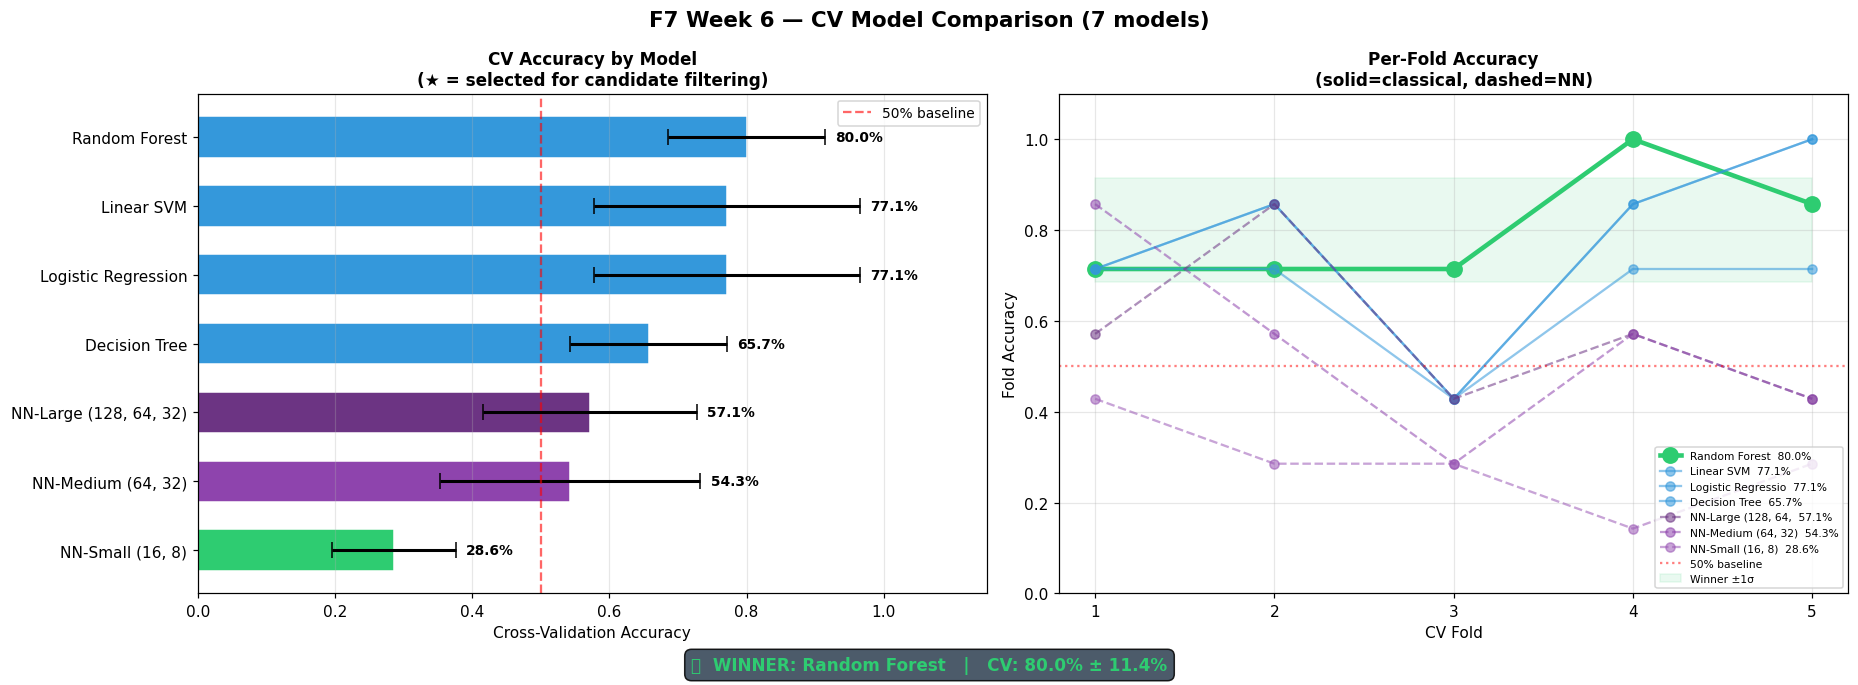

✅ Saved: F7_W6_Step7_ModelComparison.png

══════════════════════════════════════════════════════════════════════
  WINNER RATIONALE: Random Forest
══════════════════════════════════════════════════════════════════════
  CV Accuracy   : 80.0% +/- 11.4%
  Runner-up     : Linear SVM (77.1%)
  Margin        : +2.9% over runner-up

  Why this model won:
  Random Forest won, suggesting the boundary is non-linear with threshold
  effects in individual dimensions. The ensemble averaging handles noise well
  — useful when some evaluations landed in misleading regions.

  Note: Narrow win (+2.9%) — the landscape is genuinely hard to classify.
  Multiple models see similar structure. GP exploration component is important.
  The EI exploration term (sigma * phi(Z)) will carry more weight this week.

  Implication for candidate filtering (Step 8):
  Random Forest will score all 10,000 candidates by P(class=1).
  Top 50% (5,000 candidates) passed to Gaussian Process.
  GP then computes mu and sigma 

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — CV Model Comparison (7 models)',
             fontsize=14, fontweight='bold')

names  = [n for n, _ in ranked_models]
means  = [v['mean'] for _, v in ranked_models]
stds   = [v['std']  for _, v in ranked_models]
# Colour palette: winner=green, NNs=purple shades, classical=blue shades
def get_color(name, rank):
    if rank == 0: return '#2ecc71'
    if 'NN' in name: return ['#9b59b6','#8e44ad','#6c3483'][['Small','Medium','Large'].index(next((s for s in ['Small','Medium','Large'] if s in name), 'Small'))]
    return '#3498db'
bar_colors = [get_color(n, i) for i, n in enumerate(names[::-1])]

# Panel 1: Horizontal bars
ax = axes[0]
ax.barh(names[::-1], means[::-1], xerr=stds[::-1],
        color=bar_colors, edgecolor='white', height=0.6,
        capsize=5, error_kw={'linewidth':2, 'color':'#2c3e50'})
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='50% baseline')
for i, (m, s) in enumerate(zip(means[::-1], stds[::-1])):
    ax.text(m + s + 0.015, i, f'{m:.1%}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('CV Accuracy by Model\n(★ = selected for candidate filtering)', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel 2: Per-fold lines
ax = axes[1]
fold_x = np.arange(1, n_cv_folds+1)
nn_names = [n for n in names if 'NN' in n]
classical_names = [n for n in names if 'NN' not in n]
for i, (name, info) in enumerate(ranked_models):
    lw    = 3.0 if name == best_name else 1.5
    alpha = 1.0 if name == best_name else 0.55
    ms    = 10  if name == best_name else 6
    color = get_color(name, i)
    ls    = '-' if 'NN' not in name else '--'
    ax.plot(fold_x, info['scores'], f'o{ls}', color=color, linewidth=lw,
            markersize=ms, alpha=alpha, label=f'{name[:18]}  {info["mean"]:.1%}')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='50% baseline')
ax.fill_between(fold_x, best_info['mean']-best_info['std'], best_info['mean']+best_info['std'],
                alpha=0.1, color='#2ecc71', label='Winner ±1σ')
ax.set_xlabel('CV Fold'); ax.set_ylabel('Fold Accuracy')
ax.set_title('Per-Fold Accuracy\n(solid=classical, dashed=NN)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_xticks(fold_x)
ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         f'✅  WINNER: {best_name}   |   CV: {best_info["mean"]:.1%} ± {best_info["std"]:.1%}',
         ha='center', fontsize=11, color='#2ecc71', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2c3e50', alpha=0.85))

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png')
# ── Winner Rationale — documented automatically ───────────────────────────
print()
print('═'*70)
print(f'  WINNER RATIONALE: {best_name}')
print('═'*70)

# CV performance summary
margin = best_info['mean'] - ranked_models[1][1]['mean'] if len(ranked_models) > 1 else 0
runner_up = ranked_models[1][0] if len(ranked_models) > 1 else 'N/A'
print(f'  CV Accuracy   : {best_info["mean"]:.1%} +/- {best_info["std"]:.1%}')
print(f'  Runner-up     : {runner_up} ({ranked_models[1][1]["mean"]:.1%})')
print(f'  Margin        : +{margin:.1%} over runner-up')
print()

# Auto-generate rationale based on winner type
is_nn    = 'NN' in best_name
is_small = 'Small' in best_name
is_med   = 'Medium' in best_name
is_large = 'Large' in best_name
is_svm   = 'SVM' in best_name
is_rf    = 'Forest' in best_name
is_lr    = 'Logistic' in best_name
is_dt    = 'Tree' in best_name
narrow   = margin < 0.05  # less than 5% margin = narrow win

print('  Why this model won:')
if is_nn and is_small:
    print(f'  A small NN (2 hidden layers, {NN_SMALL}) won, suggesting the high/low boundary')
    print(f'  is moderately non-linear but does not require deep feature extraction.')
    print(f'  Small capacity avoids overfitting on the limited dataset ({n_samples} samples).')
elif is_nn and is_med:
    print(f'  A medium NN (2 hidden layers, {NN_MEDIUM}) won, indicating a moderately complex')
    print(f'  landscape that benefits from non-linear feature combinations.')
    print(f'  Medium capacity balances expressiveness with overfitting risk ({n_samples} samples).')
elif is_nn and is_large:
    print(f'  A large NN (3 hidden layers, {NN_LARGE}) won, suggesting a complex non-linear')
    print(f'  boundary that requires deep feature extraction to separate high/low regions.')
    print(f'  Note: with {n_samples} samples this is borderline — early stopping is critical.')
elif is_svm:
    print(f'  A Linear SVM won, suggesting the high/low value boundary is approximately')
    print(f'  linear in the standardised input space. The function landscape likely has')
    print(f'  a clean directional gradient rather than complex local structure.')
elif is_rf:
    print(f'  Random Forest won, suggesting the boundary is non-linear with threshold')
    print(f'  effects in individual dimensions. The ensemble averaging handles noise well')
    print(f'  — useful when some evaluations landed in misleading regions.')
elif is_lr:
    print(f'  Logistic Regression won, suggesting a smooth probabilistic separation')
    print(f'  between high and low regions. Well-calibrated P(class=1) output is')
    print(f'  particularly useful for filtering candidates before the GP step.')
elif is_dt:
    print(f'  Decision Tree won, suggesting the high/low boundary can be captured by')
    print(f'  axis-aligned threshold rules — one or two dimensions likely dominate.')
    print(f'  Inspect per-dimension EI curves (Step 11) to identify the key dimensions.')
else:
    print(f'  Model type: {best_name}. Review CV scores above for landscape interpretation.')

print()
if narrow:
    print(f'  Note: Narrow win (+{margin:.1%}) — the landscape is genuinely hard to classify.')
    print(f'  Multiple models see similar structure. GP exploration component is important.')
    print(f'  The EI exploration term (sigma * phi(Z)) will carry more weight this week.')
else:
    print(f'  Clear win (+{margin:.1%}) — the winning model has meaningfully better landscape')
    print(f'  understanding. Its P(class=1) scores will produce reliable candidate filtering.')

print()
print(f'  Implication for candidate filtering (Step 8):')
print(f'  {best_name} will score all {N_CANDIDATES:,} candidates by P(class=1).')
print(f'  Top {100-FILTER_PERCENTILE}% ({int(N_CANDIDATES*(1-FILTER_PERCENTILE/100)):,} candidates) passed to Gaussian Process.')
print(f'  GP then computes mu and sigma for EI/UCB acquisition (MAXIMIZATION).')
print('═'*70)


---
## 🎲 STEP 8 — Generate & Filter Candidates

We generate **10,000 candidate points** in two phases:

**80% Exploitation** — Gaussian samples tightly around the best-known point (σ=0.05 in [0,1]^d). This gives us a dense cloud near where we already know the function peaks.

**20% Exploration** — Uniform random across the full [0,1]^d space. Ensures we don't completely miss unexplored regions.

The winning classifier then **scores all 10,000 candidates** by P(high value) and we discard the bottom 50% — leaving ~5,000 "probably good" candidates for the more expensive GP step.

In [10]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

X_exploit = np.clip(best_point + np.random.normal(0, EXPLOIT_SIGMA, (n_exploit, n_dims)), 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc   = scaler.transform(X_cands)
proba_all    = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask    = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt       = X_cands[keep_mask]
proba_filt   = proba_all[keep_mask]
src_filt     = src_tag[keep_mask]

print('═'*65)
print('  CANDIDATE GENERATION & FILTERING')
print('═'*65)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
print(f'\n  → {len(X_filt):,} candidates passed to Gaussian Process')

═════════════════════════════════════════════════════════════════
  CANDIDATE GENERATION & FILTERING
═════════════════════════════════════════════════════════════════
  Generated  : 10,000  (8,000 exploit + 2,000 explore)
  Filtered by: Random Forest
  Kept       : 5,218 (top 50% by P(class=1))
  Exploit %  : 98.5%
  Prob range : [0.690, 0.950]

  → 5,218 candidates passed to Gaussian Process


---
## 🔬 STEP 9 — Gaussian Process Regression

The GP is our **probabilistic surrogate model**. It gives two outputs for any input:
- **μ (mean)** — best estimate of the true function value
- **σ (std)** — uncertainty. Near training data = low σ. Far away = high σ

**Matern 5/2 kernel** is chosen because it:
- Allows sharper transitions than the smooth RBF kernel
- Assumes the function is twice differentiable (reasonable for most BBO functions)
- Works well empirically across a wide range of black-box problems

**`normalize_y=True`** is important when function values span a wide range — it internally standardises the y-values before fitting, improving numerical stability.

**`alpha=1e-6`** is a small nugget term added to the diagonal of the kernel matrix — essential for numerical stability, equivalent to assuming very small observation noise.

In [11]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, y_std_tr = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma = gp.predict(X_filt_sc, return_std=True)

print('═'*65)
print('  GAUSSIAN PROCESS REGRESSION')
print('═'*65)
print(f'  Kernel       : Matern ν=5/2 + Constant')
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R²           : {r2:.4f}  {"✅ Good" if r2>0.7 else "⚠️ Moderate" if r2>0.4 else "❌ Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  μ range      : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  σ range      : [{sigma.min():.4f}, {sigma.max():.4f}]')

═════════════════════════════════════════════════════════════════
  GAUSSIAN PROCESS REGRESSION
═════════════════════════════════════════════════════════════════
  Kernel       : Matern ν=5/2 + Constant
  Fitted kernel: 0.944**2 * Matern(length_scale=0.713, nu=2.5)
  R²           : 1.0000  ✅ Good
  RMSE         : 0.000000
  μ range      : [0.1805, 1.3700]
  σ range      : [0.0215, 0.3523]


---
## 🎯 STEP 10 — Acquisition Functions: EI & UCB

**Expected Improvement (EI)** is our primary acquisition function:
$$EI(x) = (\mu(x) - y_{best} - \xi)\cdot\Phi(Z) + \sigma(x)\cdot\phi(Z), \quad Z = \frac{\mu(x) - y_{best} - \xi}{\sigma(x)}$$

For **MAXIMIZATION**: improvement = μ − y_best. Points where μ > y_best with high confidence give high EI (exploitation). Points where σ is large can also give high EI even if μ < y_best (exploration).

**UCB** is a simpler alternative:
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

For **MAXIMIZATION**: we **add** σ (not subtract). κ=2 means we're being optimistic up to ~2 standard deviations above the mean prediction.

In [12]:
# ── EI (Maximization) ─────────────────────────────────────────
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
exploit_term = imp * norm.cdf(Z)
explore_term = sigma * norm.pdf(Z)

# ── UCB (Maximization: add sigma) ────────────────────────────
UCB_acq = mu + UCB_KAPPA * sigma

# ── Select best (ARGMAX — Maximization) ──────────────────────
best_ei_idx  = np.argmax(EI_acq)
best_ucb_idx = np.argmax(UCB_acq)

submission = X_filt[best_ei_idx]
sub_mu     = mu[best_ei_idx]
sub_sigma  = sigma[best_ei_idx]
sub_ei     = EI_acq[best_ei_idx]
sub_ucb    = UCB_acq[best_ei_idx]
sub_exp    = exploit_term[best_ei_idx]
sub_expl   = explore_term[best_ei_idx]

print('═'*65)
print('  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)')
print('═'*65)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print()
print(f'  ★ SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  μ       : {sub_mu:.6f}   σ: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
z_sub = (sub_mu - best_value - EI_XI) / (sub_sigma + 1e-9)
print(f'  Z-score : {z_sub:.4f}')
print(f'  Exploit : {sub_exp:.6f} ({100*sub_exp/(sub_ei+1e-9):.1f}%)')
print(f'  Explore : {sub_expl:.6f} ({100*sub_expl/(sub_ei+1e-9):.1f}%)')
driver = 'EXPLOITATION' if sub_exp > sub_expl else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '✅ PREDICTS NEW BEST' if sub_mu > best_value else '✅ PREDICTS RECOVERY' if sub_mu > latest_val else '🔍 EXPLORING'
print(f'  Status  : {status}  (μ={sub_mu:.4f} vs best={best_value:.4f})')

═════════════════════════════════════════════════════════════════
  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)
═════════════════════════════════════════════════════════════════
  EI max  : 0.046261   UCB max: 1.703694
  EI > 0  : 100.0% of candidates

  ★ SELECTED (max EI):
  Coords  : [0.12500357 0.46952869 0.27018155 0.2832543  0.40526322 0.72282663]
  μ       : 1.309791   σ: 0.186364
  EI      : 0.046261   UCB: 1.682519
  Z-score : -0.3497
  Exploit : -0.023677 (-51.2%)
  Explore : 0.069938 (151.2%)
  Driver  : EXPLORATION
  Status  : ✅ PREDICTS RECOVERY  (μ=1.3098 vs best=1.3650)


---
## 📈 STEP 11 — Acquisition Curves: Global + Per Dimension

### Global acquisition curves
These show the **sorted EI and UCB scores** across all filtered candidates — how steeply one point dominates tells us how confident the GP is.

### Per-Dimension Acquisition Curves

This is a powerful diagnostic: for each dimension separately, we sweep that dimension from 0 to 1 (holding all others fixed at the best-known point) and compute how EI and UCB change.

**What to look for:**
- **Sharp peak**: that dimension has a clear optimal value — be precise here
- **Flat curve**: that dimension doesn't matter much — safe to leave near current best
- **Rising edge at boundary**: function wants this dimension pushed to 0 or 1 — be aware of boundary effects
- **Multiple peaks**: non-unimodal in that dimension — multiple good regions exist

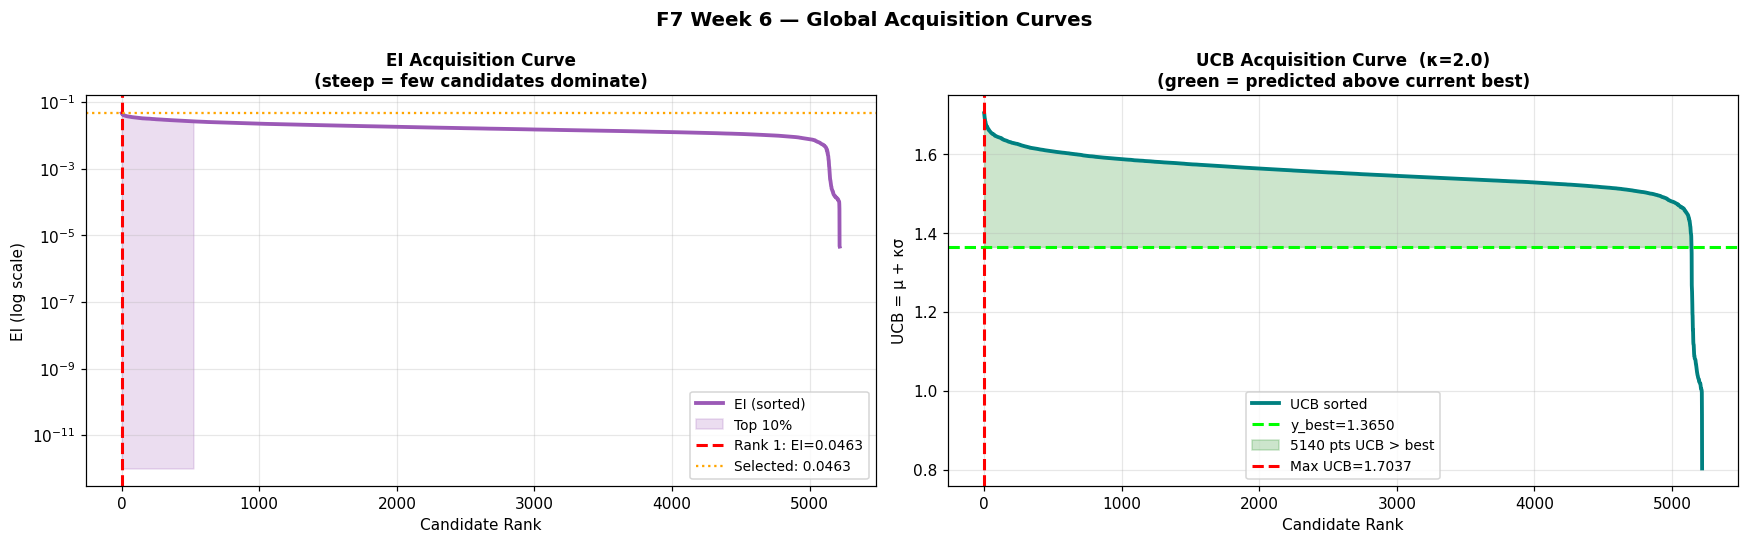

✅ Saved: F7_W6_Step11a_GlobalAcquisition.png


In [13]:
# ── Global acquisition curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Global Acquisition Curves', fontsize=13, fontweight='bold')

ei_sorted  = np.sort(EI_acq)[::-1]
ucb_sorted = np.sort(UCB_acq)[::-1]
rank_x = np.arange(1, len(ei_sorted)+1)

ax = axes[0]
ax.semilogy(rank_x, ei_sorted + 1e-12, color='#9b59b6', linewidth=2.5, label='EI (sorted)')
ax.fill_between(rank_x[:len(rank_x)//10], ei_sorted[:len(rank_x)//10]+1e-12,
                1e-12, alpha=0.2, color='#9b59b6', label='Top 10%')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Rank 1: EI={ei_sorted[0]:.4f}')
ax.axhline(sub_ei, color='orange', linewidth=1.5, linestyle=':', label=f'Selected: {sub_ei:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('EI (log scale)')
ax.set_title('EI Acquisition Curve\n(steep = few candidates dominate)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(rank_x, ucb_sorted, color='teal', linewidth=2.5, label='UCB sorted')
ax.axhline(best_value, color='lime', linewidth=2, linestyle='--',
           label=f'y_best={best_value:.4f}')
n_above = np.sum(ucb_sorted > best_value)
if n_above > 0:
    ax.fill_between(rank_x[:n_above], best_value, ucb_sorted[:n_above],
                    alpha=0.2, color='green', label=f'{n_above} pts UCB > best')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Max UCB={ucb_sorted[0]:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('UCB = μ + κσ')
ax.set_title(f'UCB Acquisition Curve  (κ={UCB_KAPPA})\n(green = predicted above current best)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png')

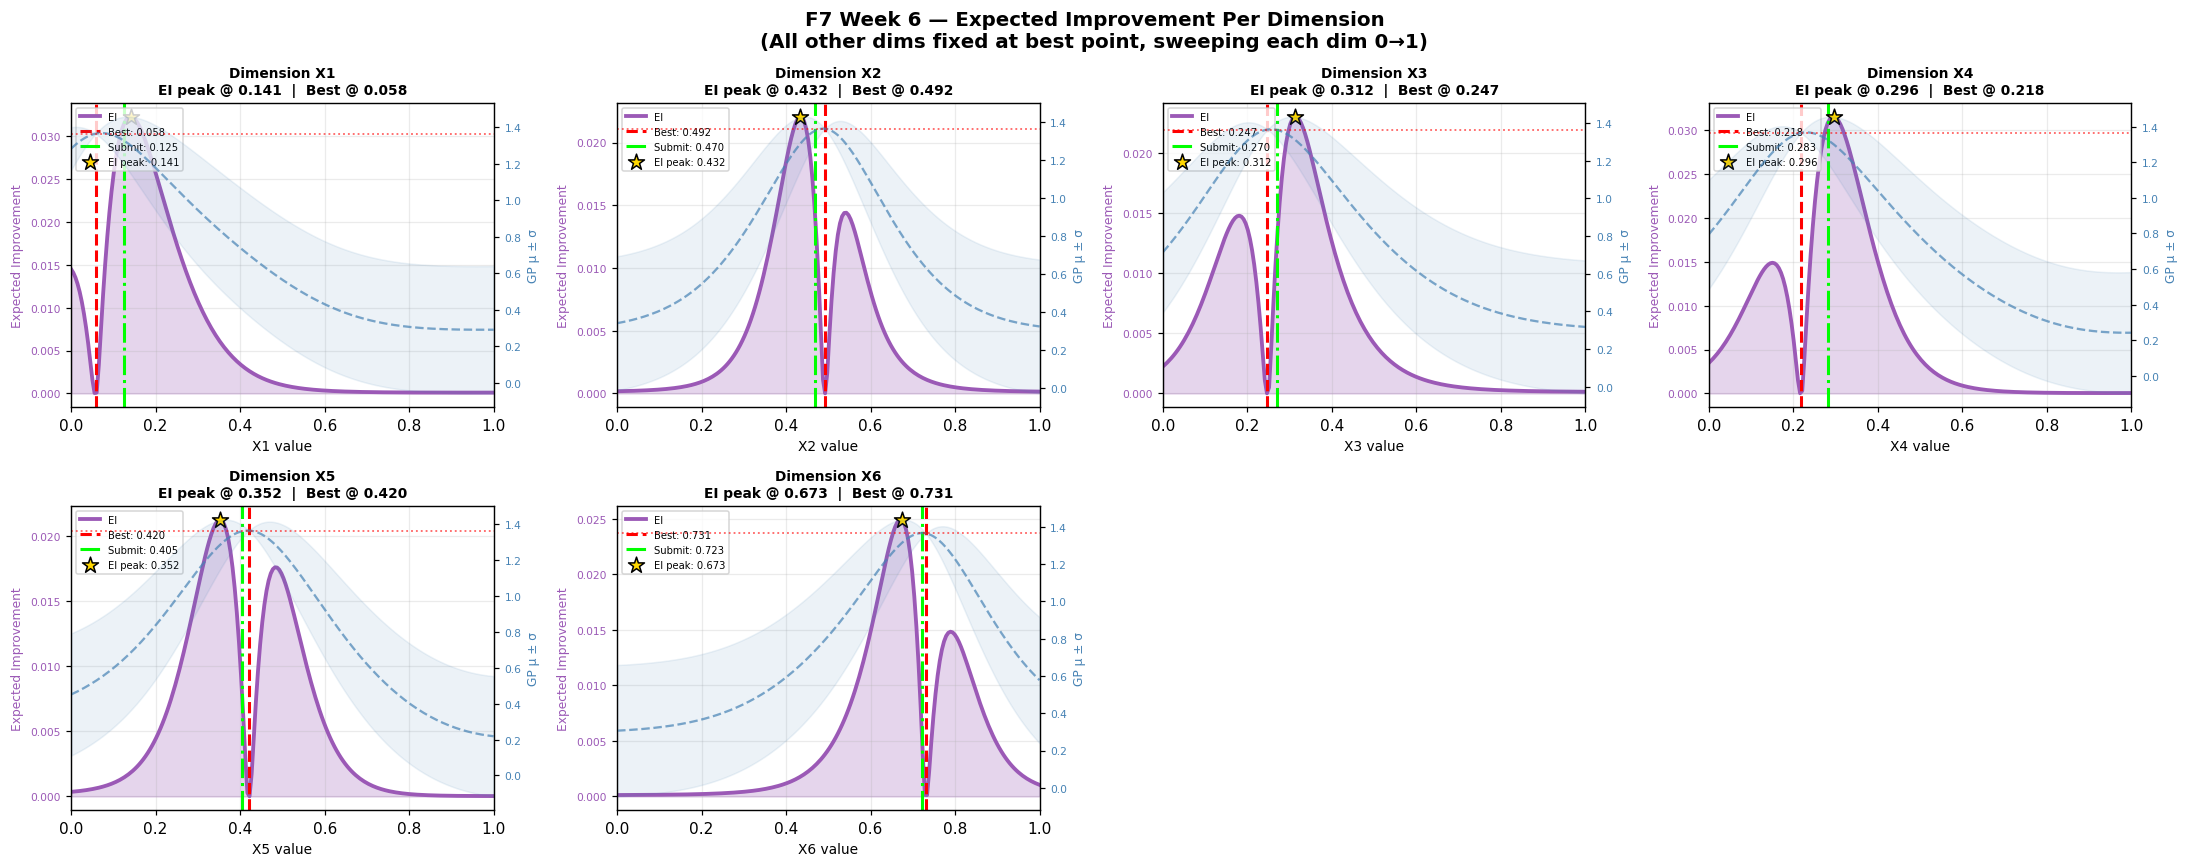

✅ Saved: F7_W6_Step11b_EI_PerDimension.png


In [14]:
# ── Per-Dimension Acquisition Curves ─────────────────────────
# For each dimension: sweep 0→1, fix all others at best_point value
# Shows how EI and UCB respond to each individual dimension

n_sweep = 200
sweep_vals = np.linspace(0, 1, n_sweep)

dim_ei_curves  = []
dim_ucb_curves = []
dim_mu_curves  = []
dim_sig_curves = []

for d in range(n_dims):
    pts = np.tile(best_point, (n_sweep, 1))
    pts[:, d] = sweep_vals
    pts_sc = scaler.transform(pts)
    mu_d, sig_d = gp.predict(pts_sc, return_std=True)
    imp_d  = mu_d - best_value - EI_XI
    Z_d    = imp_d / (sig_d + 1e-9)
    ei_d   = np.maximum(imp_d * norm.cdf(Z_d) + sig_d * norm.pdf(Z_d), 0)
    ucb_d  = mu_d + UCB_KAPPA * sig_d
    dim_ei_curves.append(ei_d)
    dim_ucb_curves.append(ucb_d)
    dim_mu_curves.append(mu_d)
    dim_sig_curves.append(sig_d)

# Determine grid layout
ncols = min(4, n_dims)
nrows_ei  = int(np.ceil(n_dims / ncols))

# ── Plot 1: EI per dimension ──────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Expected Improvement Per Dimension\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ei_d   = dim_ei_curves[d]
    sig_d  = dim_sig_curves[d]
    mu_d   = dim_mu_curves[d]

    # EI curve
    ax.fill_between(sweep_vals, 0, ei_d, alpha=0.25, color='#9b59b6')
    ax.plot(sweep_vals, ei_d, color='#9b59b6', linewidth=2.5, label='EI')

    # μ on twin axis
    ax2 = ax.twinx()
    ax2.plot(sweep_vals, mu_d, color='steelblue', linewidth=1.5, linestyle='--',
             alpha=0.7, label='GP μ')
    ax2.fill_between(sweep_vals, mu_d - sig_d, mu_d + sig_d,
                     alpha=0.1, color='steelblue')
    ax2.axhline(best_value, color='red', linestyle=':', linewidth=1.2, alpha=0.6)
    ax2.set_ylabel('GP μ ± σ', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

    # Best point value in this dim
    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    # Submission value in this dim
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    # Mark EI peak
    ei_peak_idx = np.argmax(ei_d)
    if ei_d[ei_peak_idx] > 0:
        ax.scatter(sweep_vals[ei_peak_idx], ei_d[ei_peak_idx],
                   c='gold', s=120, marker='*', zorder=5,
                   edgecolors='black', linewidths=1,
                   label=f'EI peak: {sweep_vals[ei_peak_idx]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('Expected Improvement', color='#9b59b6', fontsize=8)
    ax.tick_params(axis='y', labelcolor='#9b59b6', labelsize=7)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nEI peak @ {sweep_vals[np.argmax(ei_d)]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png')

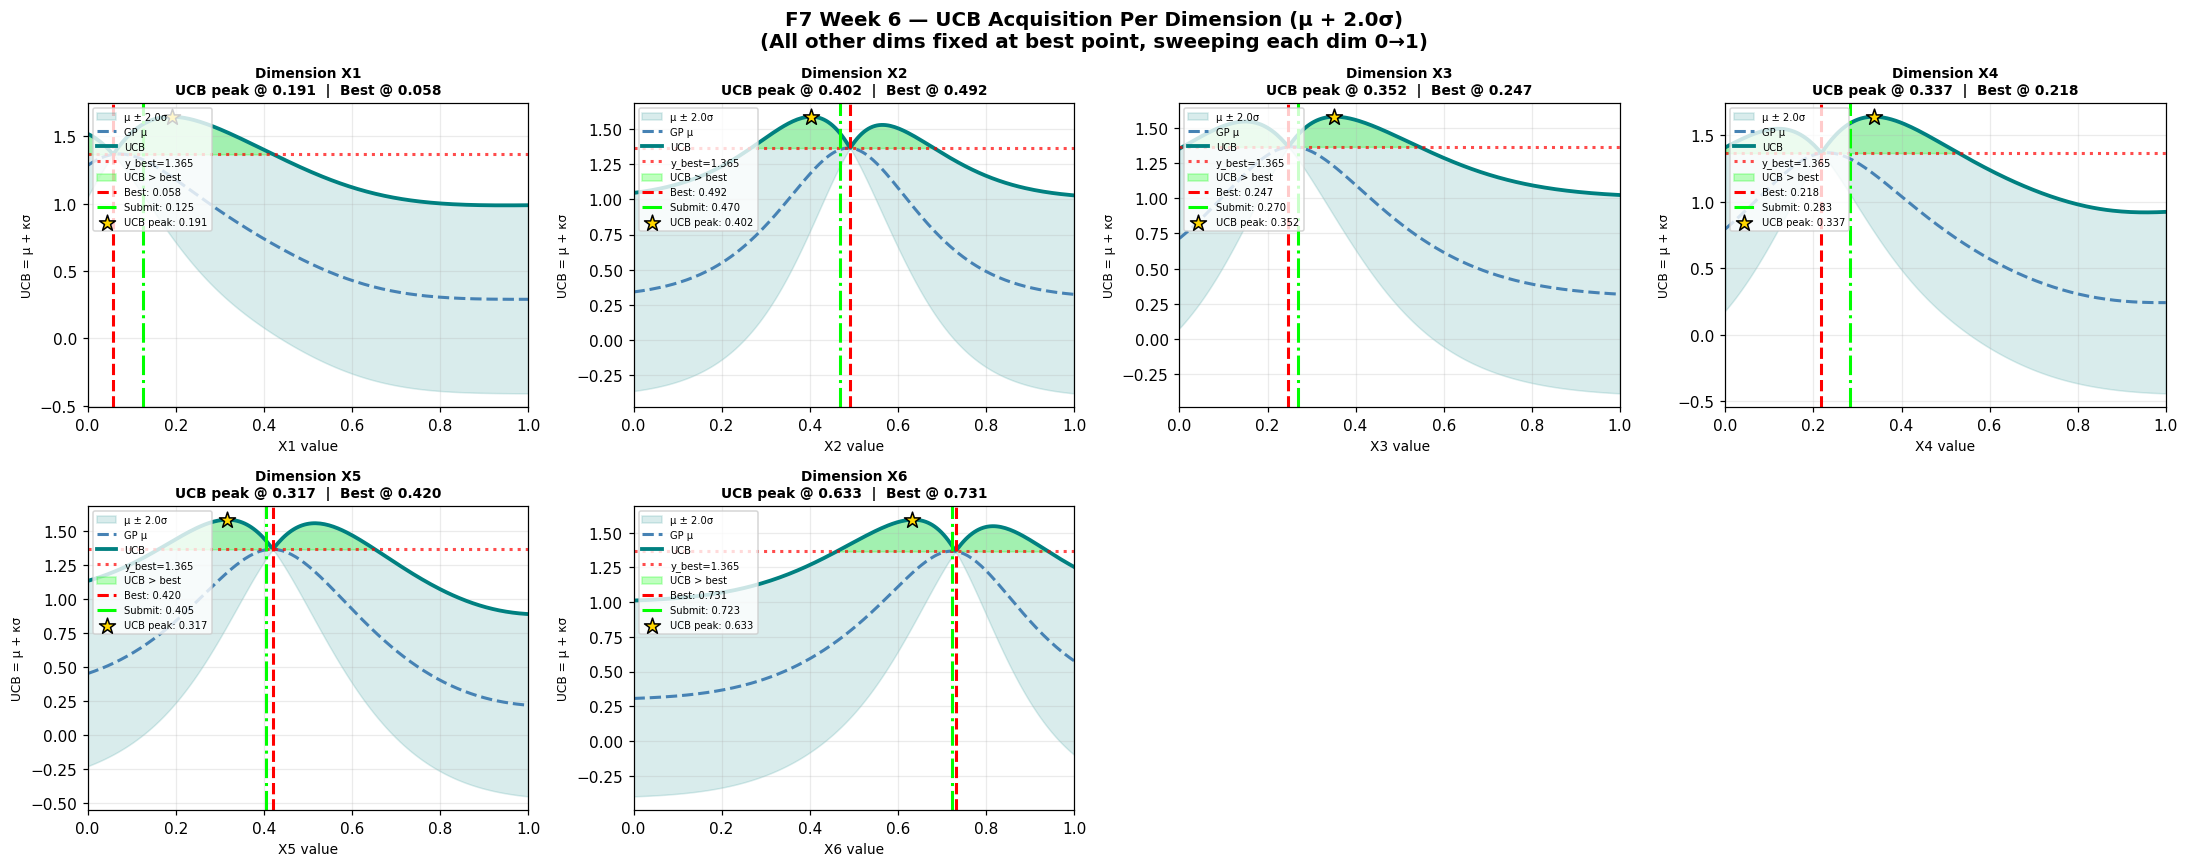

✅ Saved: F7_W6_Step11c_UCB_PerDimension.png

  PER-DIMENSION SUMMARY:
  Dim      Best val    EI peak   UCB peak    Agreement
  ────────────────────────────────────────────────────
  X1         0.0579     0.1407     0.1910      ✅ agree
  X2         0.4917     0.4322     0.4020      ✅ agree
  X3         0.2474     0.3116     0.3518      ✅ agree
  X4         0.2181     0.2965     0.3367      ✅ agree
  X5         0.4204     0.3518     0.3166      ✅ agree
  X6         0.7310     0.6734     0.6332      ✅ agree


In [15]:
# ── Plot 2: UCB per dimension ─────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — UCB Acquisition Per Dimension (μ + {UCB_KAPPA}σ)\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ucb_d = dim_ucb_curves[d]
    mu_d  = dim_mu_curves[d]
    sig_d = dim_sig_curves[d]

    ax.fill_between(sweep_vals, mu_d - UCB_KAPPA*sig_d, mu_d + UCB_KAPPA*sig_d,
                    alpha=0.15, color='teal', label=f'μ ± {UCB_KAPPA}σ')
    ax.plot(sweep_vals, mu_d, color='steelblue', linewidth=2, linestyle='--', label='GP μ')
    ax.plot(sweep_vals, ucb_d, color='teal', linewidth=2.5, label='UCB')
    ax.axhline(best_value, color='red', linestyle=':', linewidth=2,
               alpha=0.7, label=f'y_best={best_value:.3f}')

    # Shade region where UCB > best
    above = ucb_d > best_value
    if np.any(above):
        ax.fill_between(sweep_vals, best_value, ucb_d, where=above,
                        alpha=0.25, color='lime', label='UCB > best')

    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    ucb_peak = np.argmax(ucb_d)
    ax.scatter(sweep_vals[ucb_peak], ucb_d[ucb_peak], c='gold', s=120,
               marker='*', zorder=5, edgecolors='black', linewidths=1,
               label=f'UCB peak: {sweep_vals[ucb_peak]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('UCB = μ + κσ', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nUCB peak @ {sweep_vals[ucb_peak]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png')

# Summary table
print()
print('  PER-DIMENSION SUMMARY:')
print(f'  {"Dim":<6} {"Best val":>10} {"EI peak":>10} {"UCB peak":>10} {"Agreement":>12}')
print('  ' + '─'*52)
for d in range(n_dims):
    ei_peak  = sweep_vals[np.argmax(dim_ei_curves[d])]
    ucb_peak = sweep_vals[np.argmax(dim_ucb_curves[d])]
    agree    = '✅ agree' if abs(ei_peak - ucb_peak) < 0.1 else '⚠️ differ'
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {ei_peak:>10.4f} {ucb_peak:>10.4f} {agree:>12}')

---
## 🗺️ STEP 12 — Acquisition Surface Visualisations

For the **two most sensitive dimensions** (found by GP gradient analysis), we plot 2D contour surfaces of μ, EI, and UCB. All other dimensions are fixed at the best-known values.

This gives us a direct spatial view of where the GP thinks the landscape peaks and where the acquisition functions want us to go next.

  Top 2 sensitive dims: X4 (0.4849), X1 (0.4847)


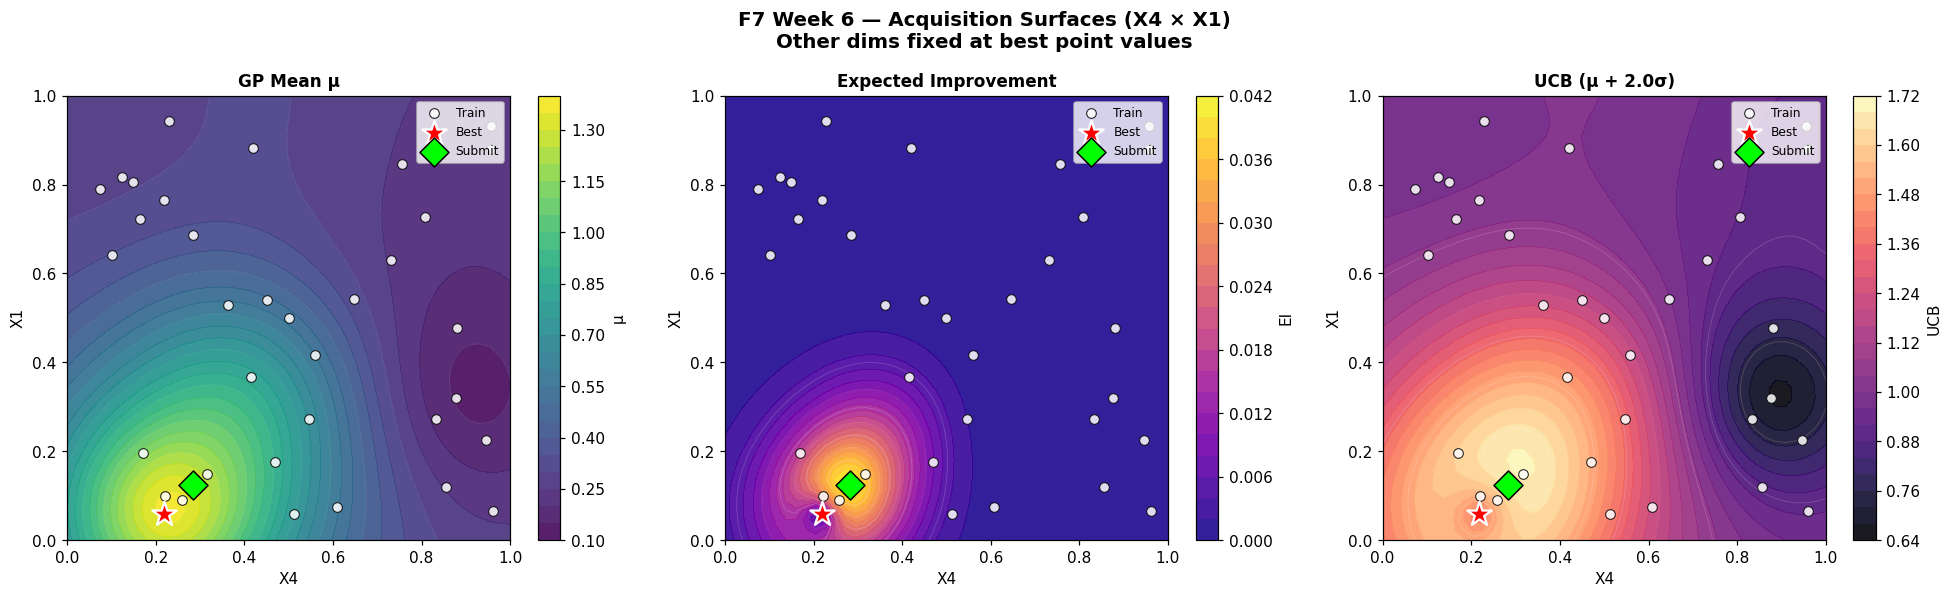

✅ Saved: F7_W6_Step12_AcquisitionSurface.png


In [16]:
# Sensitivity analysis to find top 2 dims
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = top2[0], top2[1]

print(f'  Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

# Build grid
g_res = 45
g1, g2 = np.linspace(0,1,g_res), np.linspace(0,1,g_res)
G1, G2 = np.meshgrid(g1, g2)
grid_pts = np.tile(best_point, (g_res*g_res, 1))
grid_pts[:, d1] = G1.ravel(); grid_pts[:, d2] = G2.ravel()
grid_sc = scaler.transform(grid_pts)
mg, sg = gp.predict(grid_sc, return_std=True)
ig = mg - best_value - EI_XI; Zg = ig/(sg+1e-9)
EIg = np.maximum(ig*norm.cdf(Zg) + sg*norm.pdf(Zg), 0)
UCBg = mg + UCB_KAPPA*sg

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Acquisition Surfaces (X{d1+1} × X{d2+1})\n'
             f'Other dims fixed at best point values', fontsize=13, fontweight='bold')

for ax, Z_grid, title, cmap, clabel in [
    (axes[0], mg.reshape(g_res,g_res),   f'GP Mean μ', 'viridis', 'μ'),
    (axes[1], EIg.reshape(g_res,g_res),  'Expected Improvement', 'plasma', 'EI'),
    (axes[2], UCBg.reshape(g_res,g_res), f'UCB (μ + {UCB_KAPPA}σ)', 'magma', 'UCB'),
]:
    cf  = ax.contourf(G1, G2, Z_grid, levels=25, cmap=cmap, alpha=0.9)
    ax.contour(G1, G2, Z_grid, levels=8, colors='white', alpha=0.2, linewidths=0.5)
    plt.colorbar(cf, ax=ax, label=clabel)
    ax.scatter(X_train[:,d1], X_train[:,d2], c='white', s=40,
               edgecolors='black', linewidths=0.7, zorder=4, alpha=0.85, label='Train')
    ax.scatter(best_point[d1], best_point[d2], c='red', s=280, marker='*',
               zorder=5, edgecolors='white', linewidths=1.5, label=f'Best')
    ax.scatter(submission[d1], submission[d2], c='lime', s=180, marker='D',
               zorder=6, edgecolors='black', linewidths=1, label='Submit')
    ax.set_xlabel(f'X{d1+1}'); ax.set_ylabel(f'X{d2+1}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png')

---
## 🏆 STEP 13 — Top Candidates & Submission Dashboard

Final review: top 5 candidates by EI, then the full submission dashboard combining all key information.

The dashboard gives a complete at-a-glance view: historical trajectory, predicted outcome, submission coordinates, EI decomposition, and all key metrics in a summary table.

In [17]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('═'*70)
print('  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)')
print('═'*70)
print(f'  {"Rank":<6} {"EI":>10} {"GP μ":>10} {"GP σ":>10} {"UCB":>10}  Source')
print('  ' + '─'*58)
for rank, idx in enumerate(top5, 1):
    star = '★' if rank == 1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f} {UCB_acq[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx]}')
    print()

══════════════════════════════════════════════════════════════════════
  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)
══════════════════════════════════════════════════════════════════════
  Rank           EI       GP μ       GP σ        UCB  Source
  ──────────────────────────────────────────────────────────
  ★#1      0.046261     1.3098     0.1864     1.6825  exploit
          [0.12500357 0.46952869 0.27018155 0.2832543  0.40526322 0.72282663]

   #2      0.045224     1.3071     0.1862     1.6795  exploit
          [0.13639903 0.49182005 0.28788075 0.27177747 0.39072896 0.71155761]

   #3      0.045196     1.3168     0.1767     1.6702  exploit
          [0.10841392 0.47847119 0.29989962 0.26284785 0.39203393 0.68664741]

   #4      0.044289     1.2723     0.2157     1.7037  exploit
          [0.14057833 0.45746749 0.29178146 0.29084268 0.42907639 0.72696927]

   #5      0.044009     1.3192     0.1712     1.6616  exploit
          [0.12618367 0.49414939 0.30340727 0.27494909 0.41472378 0

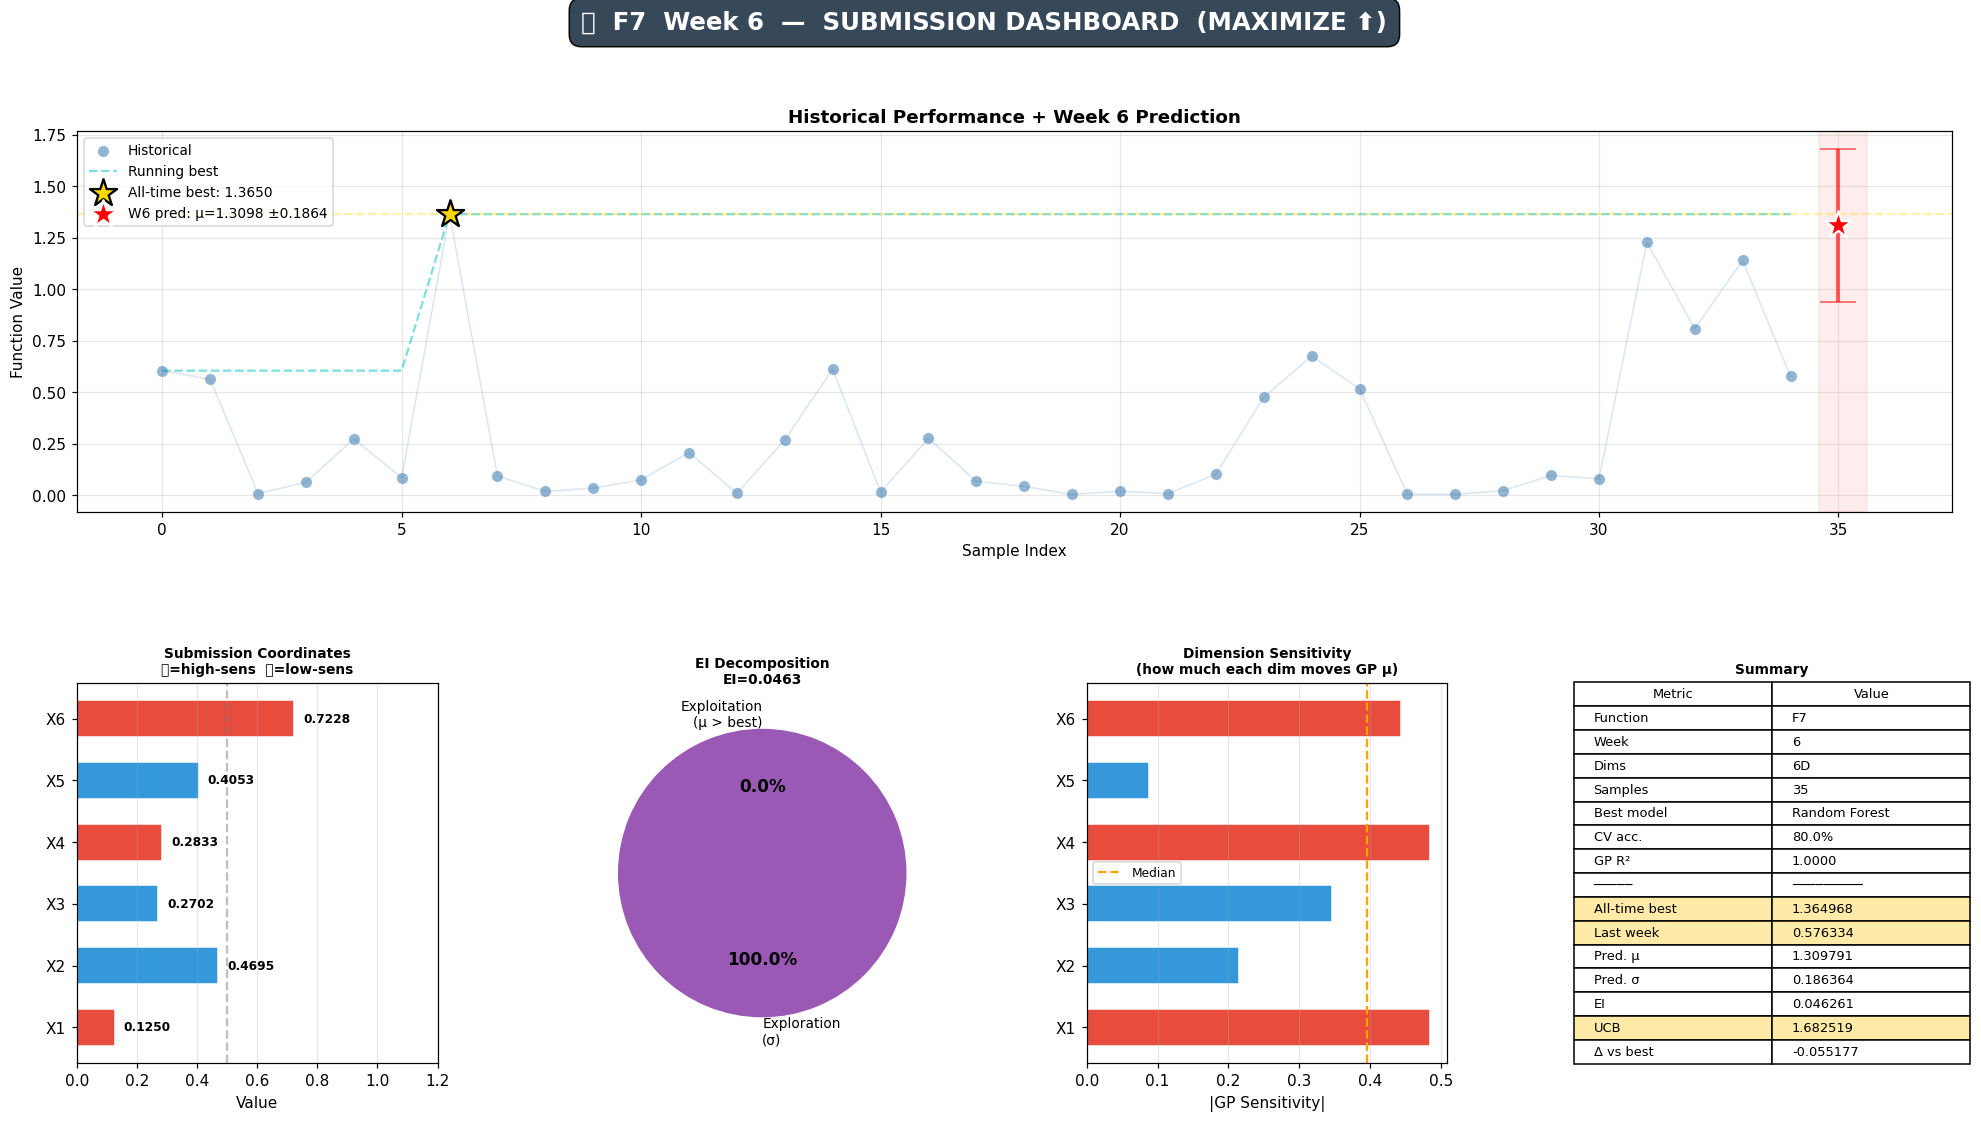

✅ Saved: F7_W6_Step13_Dashboard.png


In [18]:
# ── Submission Dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(22, 11))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)
fig.suptitle(f'🎯  {FUNCTION_ID}  Week {WEEK}  —  SUBMISSION DASHBOARD  (MAXIMIZE ⬆️)',
             fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50', alpha=0.95))

# Panel 1: Full history + prediction
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(indices, y_train, c='steelblue', s=55, alpha=0.6, zorder=3,
            edgecolors='white', linewidths=0.3, label='Historical')
ax1.plot(indices, y_train, 'steelblue', alpha=0.2, linewidth=1)
ax1.plot(indices, np.maximum.accumulate(y_train), 'c--', linewidth=1.5, alpha=0.5, label='Running best')
ax1.scatter(best_idx, best_value, c='gold', s=350, marker='*', zorder=6,
            edgecolors='black', linewidths=1.5, label=f'All-time best: {best_value:.4f}')
ax1.errorbar(n_samples, sub_mu, yerr=2*sub_sigma,
             fmt='none', color='red', capsize=12, linewidth=2.5, alpha=0.65)
ax1.scatter(n_samples, sub_mu, c='red', s=350, marker='*', zorder=6,
            edgecolors='white', linewidths=1.5,
            label=f'W{WEEK} pred: μ={sub_mu:.4f} ±{sub_sigma:.4f}')
ax1.axhline(best_value, color='gold', linestyle='--', alpha=0.35, linewidth=1.5)
ax1.axvspan(n_samples-0.4, n_samples+0.6, alpha=0.07, color='red')
ax1.set_xlabel('Sample Index'); ax1.set_ylabel('Function Value')
ax1.set_title(f'Historical Performance + Week {WEEK} Prediction', fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='upper left'); ax1.grid(True, alpha=0.3)

# Panel 2: Submission coordinates
ax2 = fig.add_subplot(gs[1, 0])
dim_labels = [f'X{i+1}' for i in range(n_dims)]
sens_arr = np.array(sensitivities)
c_bars   = ['#e74c3c' if s > np.median(sens_arr) else '#3498db' for s in sens_arr]
ax2.barh(dim_labels, submission, color=c_bars, edgecolor='white', height=0.6)
for i, v in enumerate(submission):
    ax2.text(min(v+0.03, 1.1), i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1.2); ax2.set_xlabel('Value')
ax2.set_title('Submission Coordinates\n🔴=high-sens  🔵=low-sens', fontweight='bold', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# Panel 3: EI decomposition
ax3 = fig.add_subplot(gs[1, 1])
if sub_exp > 0 or sub_expl > 0:
    wedges, texts, autos = ax3.pie(
        [max(sub_exp,0), max(sub_expl,0)],
        labels=['Exploitation\n(μ > best)', 'Exploration\n(σ)'],
        colors=['#2ecc71','#9b59b6'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':9})
    for a in autos: a.set_fontsize(11); a.set_fontweight('bold')
ax3.set_title(f'EI Decomposition\nEI={sub_ei:.4f}', fontweight='bold', fontsize=9)

# Panel 4: Dim sensitivities
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(dim_labels, sens_arr, color=c_bars, edgecolor='white', height=0.6)
ax4.axvline(np.median(sens_arr), color='orange', linestyle='--', linewidth=1.5, label='Median')
ax4.set_xlabel('|GP Sensitivity|')
ax4.set_title('Dimension Sensitivity\n(how much each dim moves GP μ)', fontweight='bold', fontsize=9)
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='x')

# Panel 5: Summary table
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis('off')
rows = [
    ['Function',    FUNCTION_ID],
    ['Week',        str(WEEK)],
    ['Dims',        f'{n_dims}D'],
    ['Samples',     str(n_samples)],
    ['Best model',  best_name[:16]],
    ['CV acc.',     f'{best_info["mean"]:.1%}'],
    ['GP R²',       f'{r2:.4f}'],
    ['─────',       '─────────'],
    ['All-time best', f'{best_value:.6f}'],
    ['Last week',   f'{latest_val:.6f}'],
    ['Pred. μ',     f'{sub_mu:.6f}'],
    ['Pred. σ',     f'{sub_sigma:.6f}'],
    ['EI',          f'{sub_ei:.6f}'],
    ['UCB',         f'{sub_ucb:.6f}'],
    ['Δ vs best',   f'{sub_mu-best_value:+.6f}'],
]
tbl = ax5.table(cellText=rows, colLabels=['Metric','Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 1.3)
for r in [9, 10, 14]:
    for c in [0,1]:
        try: tbl[r,c].set_facecolor('#ffeaa7')
        except: pass
ax5.set_title('Summary', fontweight='bold', fontsize=9)

plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png')

---
## 📋 STEP 14 — Final Formatted Submission

The winning point formatted as a dash-separated string — ready to copy directly into the BBO submission interface.

Saved as both `.npy` (for reuse in future notebooks) and `.txt` (for submission).

In [19]:
submission_str = '-'.join([f'{x:.6f}' for x in submission])

print('╔' + '═'*66 + '╗')
print(f'║  WEEK {WEEK} FINAL SUBMISSION — {FUNCTION_ID}{" "*(55 - len(FUNCTION_ID) - len(str(WEEK)))}║')
print('╠' + '═'*66 + '╣')
print(f'║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE ⬆️{" "*4}║')
print(f'║  Best model : {best_name:<25}  CV = {best_info["mean"]:.1%}{" "*8}║')
print(f'║  GP R²      : {r2:.4f}{" "*50}║')
print('╠' + '═'*66 + '╣')
print(f'║  GP μ       : {sub_mu:.6f}{" "*48}║')
print(f'║  GP σ       : {sub_sigma:.6f}{" "*48}║')
print(f'║  UCB        : {sub_ucb:.6f}{" "*48}║')
print(f'║  EI         : {sub_ei:.6f}{" "*48}║')
print('╠' + '═'*66 + '╣')
print(f'║  All-time best : {best_value:.6f}{" "*44}║')
print(f'║  Last week     : {latest_val:.6f}{" "*44}║')
print(f'║  Δ vs best     : {sub_mu - best_value:+.6f}{" "*44}║')
print('╠' + '═'*66 + '╣')
if sub_mu > best_value:
    msg = f'✅  GP PREDICTS NEW BEST: {sub_mu:.4f} > {best_value:.4f}'
elif sub_mu > latest_val:
    msg = f'✅  GP PREDICTS RECOVERY: {sub_mu:.4f} > {latest_val:.4f}'
else:
    msg = f'🔍  EXPLORING UNCERTAIN REGION  μ={sub_mu:.4f}'
print(f'║  {msg:<65}║')
print('╠' + '═'*66 + '╣')
print(f'║  📋  COPY THIS TO SUBMIT:{" "*41}║')
print(f'║{" "*68}║')
print(f'║  {submission_str:<66}║')
print(f'║{" "*68}║')
print('╚' + '═'*66 + '╝')

# Save
np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | Method: Adaptive+GP/EI | MAXIMIZE\n')
    f.write(f'# Model: {best_name} CV={best_info["mean"]:.1%} | GP R2={r2:.4f}\n')
    f.write(f'# mu={sub_mu:.6f} sigma={sub_sigma:.6f} EI={sub_ei:.6f}\n')
    f.write(f'# best={best_value:.6f} delta={sub_mu-best_value:+.6f}\n')
    f.write(submission_str + '\n')

print(f'\n  💾 {FUNCTION_ID}_W{WEEK}_submission.npy')
print(f'  💾 {FUNCTION_ID}_W{WEEK}_submission.txt')
print()
print('  📊 ALL VISUALISATIONS:')
for step, name in [
    ('Step3',  'History'),
    ('Step6',  'ModelPredictions'),
    ('Step7',  'ModelComparison'),
    ('Step11a','GlobalAcquisition'),
    ('Step11b','EI_PerDimension'),
    ('Step11c','UCB_PerDimension'),
    ('Step12', 'AcquisitionSurface'),
    ('Step13', 'Dashboard'),
]:
    print(f'     {FUNCTION_ID}_W{WEEK}_{step}_{name}.png')

print()
print('  🎯  MAXIMIZATION — HIGHER IS ALWAYS BETTER ⬆️')

╔══════════════════════════════════════════════════════════════════╗
║  WEEK 6 FINAL SUBMISSION — F7                                                    ║
╠══════════════════════════════════════════════════════════════════╣
║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE ⬆️    ║
║  Best model : Random Forest              CV = 80.0%        ║
║  GP R²      : 1.0000                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  GP μ       : 1.309791                                                ║
║  GP σ       : 0.186364                                                ║
║  UCB        : 1.682519                                                ║
║  EI         : 0.046261                                                ║
╠══════════════════════════════════════════════════════════════════╣
║  All-time best : 1.364968                                            ║
║  Last week     : 0.576334                                       

---
## 💾 STEP 15 — Save Hyperparameter Record & Visualisation Index

### Why Keep a Hyperparameter Record?

Each week we tune parameters based on what we've learned. Without a written record it's impossible to:
- Know **why** a particular week performed well or poorly
- Compare parameter choices across weeks systematically
- Reproduce a run that gave a good result
- Build intuition about which settings work for which function types

This step saves a **complete, self-contained record** of everything used in this run:
- All hyperparameter values with their rationale
- GP kernel specification (fitted parameters, not just defaults)
- Model CV results for all 7 classifiers
- Selected model and its performance
- Submission point, predictions, and context
- Index of all visualisation files produced

Saved as: `{FUNCTION_ID}_W{WEEK}_hyperparameters.json` and `{FUNCTION_ID}_W{WEEK}_run_report.txt`

In [20]:
import json as _json
import os
from datetime import datetime

# ── 1. Collect all visualisation files produced ───────────────
viz_files = [
    f'{FUNCTION_ID}_W{WEEK}_Step3_History.png',
    f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png',
    f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png',
    f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png',
]
viz_status = {f: os.path.exists(f) for f in viz_files}

# ── 2. GP kernel details ──────────────────────────────────────
kernel_str  = str(gp.kernel_)
kernel_init = str(gp.kernel)
gp_params   = gp.kernel_.get_params()
# Extract fitted length scale and amplitude cleanly
gp_param_clean = {k: float(v) if hasattr(v, '__float__') else str(v)
                  for k, v in gp_params.items()}

# ── 3. Model CV results ───────────────────────────────────────
model_records = {}
for name, info in cv_results.items():
    model_records[name] = {
        'cv_mean'   : round(float(info['mean']), 6),
        'cv_std'    : round(float(info['std']),  6),
        'cv_folds'  : [round(float(s), 6) for s in info['scores']],
        'selected'  : name == best_name,
        'type'      : 'neural_network' if 'NN' in name else 'classical',
    }

# ── 4. Dimension analysis ─────────────────────────────────────
dim_records = {}
for d in range(n_dims):
    ei_peak_val  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
    ucb_peak_val = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
    dim_records[f'X{d+1}'] = {
        'best_point_value' : round(float(best_point[d]), 6),
        'submission_value' : round(float(submission[d]), 6),
        'gp_sensitivity'   : round(float(sensitivities[d]), 6),
        'ei_peak_at'       : round(ei_peak_val, 6),
        'ucb_peak_at'      : round(ucb_peak_val, 6),
        'ei_ucb_agree'     : abs(ei_peak_val - ucb_peak_val) < 0.1,
    }

# ── 5. Build full hyperparameter record ──────────────────────
record = {
    'meta': {
        'function_id'   : FUNCTION_ID,
        'week'          : WEEK,
        'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input_file'    : INPUT_FILE,
        'output_file'   : OUTPUT_FILE,
        'objective'     : 'MAXIMIZE',
    },
    'data': {
        'n_samples'     : int(n_samples),
        'n_dims'        : int(n_dims),
        'np_ratio'      : round(float(n_samples / n_dims), 4),
        'y_min'         : round(float(y_train.min()), 8),
        'y_max'         : round(float(y_train.max()), 8),
        'y_mean'        : round(float(y_train.mean()), 8),
        'y_std'         : round(float(y_train.std()),  8),
        'best_value'    : round(float(best_value),     8),
        'best_idx'      : int(best_idx),
        'best_point'    : [round(float(v), 8) for v in best_point],
        'latest_value'  : round(float(latest_val),    8),
    },
    'hyperparameters': {
        'TOP_PERCENTILE': {
            'value'    : TOP_PERCENTILE,
            'purpose'  : 'Fraction of samples labelled class 1. Top X% = HIGH values = GOOD.',
            'rationale': f'Top {TOP_PERCENTILE}% gives {n_pos} positive samples. '
                          f'Balances selectivity vs having enough training signal.'
        },
        'N_CANDIDATES': {
            'value'    : N_CANDIDATES,
            'purpose'  : 'Total candidate pool size evaluated by classifier+GP before selecting 1 to submit.',
            'rationale': f'{N_CANDIDATES:,} provides dense coverage in {n_dims}D space. '
                          f'Larger = better coverage but slower GP.'
        },
        'EXPLOIT_RATIO': {
            'value'    : EXPLOIT_RATIO,
            'purpose'  : 'Fraction of candidates sampled near best-known point (exploitation) vs random (exploration).',
            'rationale': f'{int(EXPLOIT_RATIO*100)}% exploitation justified at Week {WEEK} — strong best point established. '
                          f'Early weeks: 0.6-0.7. Later weeks: 0.8-0.9.'
        },
        'EXPLOIT_SIGMA': {
            'value'    : EXPLOIT_SIGMA,
            'purpose'  : 'Gaussian std dev for exploitation sampling around best point.',
            'rationale': f'sigma={EXPLOIT_SIGMA} in [0,1]^{n_dims} creates ±{2*EXPLOIT_SIGMA:.2f} search radius. '
                          f'Tight enough to stay near best, loose enough to find local improvements.'
        },
        'UCB_KAPPA': {
            'value'    : UCB_KAPPA,
            'purpose'  : 'Exploration weight in UCB = mu + kappa*sigma. Higher = more exploratory.',
            'rationale': f'kappa={UCB_KAPPA} ~ 95% CI. Standard choice for Week {WEEK}. '
                          f'Use 3-5 early in search, 1-2 when exploiting known best region.'
        },
        'EI_XI': {
            'value'    : EI_XI,
            'purpose'  : 'Exploration jitter in EI. EI = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z).',
            'rationale': f'xi={EI_XI} prevents EI from over-committing to tiny improvements near best. '
                          f'Small value: slight nudge toward exploration.'
        },
        'GP_RESTARTS': {
            'value'    : GP_RESTARTS,
            'purpose'  : 'Random restarts for GP kernel hyperparameter optimisation.',
            'rationale': f'{GP_RESTARTS} restarts balances fit quality vs runtime. '
                          f'Use 10+ for final weeks when GP quality is critical.'
        },
        'FILTER_PERCENTILE': {
            'value'    : FILTER_PERCENTILE,
            'purpose'  : 'Discard bottom X% of candidates by classifier P(class=1) before GP.',
            'rationale': f'Keeps {int(N_CANDIDATES*(1-FILTER_PERCENTILE/100)):,} of {N_CANDIDATES:,} for GP. '
                          f'Removes clearly bad regions efficiently.'
        },
        'NN_ARCHITECTURES': {
            'small'    : list(NN_SMALL),
            'medium'   : list(NN_MEDIUM),
            'large'    : list(NN_LARGE),
            'purpose'  : 'Three NN sizes tested to match function landscape complexity.',
            'rationale': 'Small=simple/linear landscapes. Medium=general purpose. '
                          'Large=highly non-linear. Early stopping prevents overfitting.'
        },
    },
    'gp_kernel': {
        'type'          : 'ConstantKernel * Matern(nu=2.5)',
        'nu'            : 2.5,
        'initial_spec'  : kernel_init,
        'fitted_spec'   : kernel_str,
        'fitted_params' : gp_param_clean,
        'normalize_y'   : True,
        'alpha_nugget'  : 1e-6,
        'n_restarts'    : GP_RESTARTS,
        'train_r2'      : round(float(r2), 6),
        'train_rmse'    : round(float(rmse), 8),
        'rationale'     : 'Matern 5/2 is robust for BBO: allows sharp transitions, '
                           'assumes twice-differentiable function. ConstantKernel scales amplitude. '
                           'normalize_y stabilises fitting when y range is large.'
    },
    'classification': {
        'n_cv_folds'         : int(n_cv_folds),
        'label_threshold'    : round(float(threshold), 8),
        'n_positive_class1'  : int(n_pos),
        'n_negative_class0'  : int(n_samples - n_pos),
        'selected_model'     : best_name,
        'selected_cv_mean'   : round(float(best_info['mean']), 6),
        'selected_cv_std'    : round(float(best_info['std']),  6),
        'all_model_results'  : model_records,
    },
    'candidates': {
        'total_generated'  : int(N_CANDIDATES),
        'n_exploit'        : int(int(N_CANDIDATES * EXPLOIT_RATIO)),
        'n_explore'        : int(N_CANDIDATES - int(N_CANDIDATES * EXPLOIT_RATIO)),
        'after_filter'     : int(len(X_filt)),
        'filter_model'     : best_name,
    },
    'acquisition': {
        'method'               : 'Expected Improvement (primary) + UCB (reference)',
        'ei_formula'           : 'EI(x) = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z), Z=(mu-y_best-xi)/sigma',
        'ucb_formula'          : f'UCB(x) = mu + {UCB_KAPPA}*sigma',
        'direction'            : 'MAXIMIZE — argmax EI',
        'ei_max'               : round(float(EI_acq.max()), 8),
        'ucb_max'              : round(float(UCB_acq.max()), 8),
        'pct_positive_ei'      : round(float(100*np.mean(EI_acq>0)), 2),
    },
    'submission': {
        'point'            : [round(float(v), 8) for v in submission],
        'formatted_string' : submission_str,
        'gp_mu'            : round(float(sub_mu),    8),
        'gp_sigma'         : round(float(sub_sigma), 8),
        'ei'               : round(float(sub_ei),    8),
        'ucb'              : round(float(sub_ucb),   8),
        'exploit_term'     : round(float(sub_exp),   8),
        'explore_term'     : round(float(sub_expl),  8),
        'ei_driver'        : 'exploitation' if sub_exp > sub_expl else 'exploration',
        'delta_vs_best'    : round(float(sub_mu - best_value), 8),
        'prediction'       : 'new_best' if sub_mu > best_value else
                              'recovery' if sub_mu > latest_val else 'exploration',
    },
    'dimensions': dim_records,
    'visualisations': {
        f: {'exists': viz_status[f], 'description': desc}
        for f, desc in zip(viz_files, [
            'Historical performance: all evaluations, running best, value distribution',
            'All 7 model P(class=1) prediction distributions + agreement correlation matrix',
            'CV accuracy bar chart + per-fold accuracy lines for all 7 models',
            'Global EI acquisition curve (log) and UCB acquisition curve (sorted)',
            'EI acquisition curve per dimension — sweeping each dim 0→1',
            'UCB acquisition curve per dimension — sweeping each dim 0→1',
            'GP mean, EI, UCB contour surfaces on top-2 sensitive dimensions',
            'Full submission dashboard: history, coordinates, EI decomp, summary table',
        ])
    },
}

# ── 6. Save JSON ──────────────────────────────────────────────
json_fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(json_fname, 'w', encoding='utf-8') as fp:
    _json.dump(record, fp, indent=2)
print(f'✅ Saved JSON : {json_fname}')

# ── 7. Save human-readable text report ───────────────────────
txt_fname = f'{FUNCTION_ID}_W{WEEK}_run_report.txt'
with open(txt_fname, 'w', encoding='utf-8') as fp:
    def w(s=''): fp.write(s + '\n')
    w('=' * 70)
    w(f'  BBO RUN REPORT — {FUNCTION_ID}  Week {WEEK}')
    w(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    w('=' * 70)
    w()
    w('── DATA ────────────────────────────────────────────────────────────')
    w(f'  Function    : {FUNCTION_ID}')
    w(f'  Week        : {WEEK}')
    w(f'  Samples     : {n_samples}  |  Dims: {n_dims}D  |  n/p: {n_samples/n_dims:.2f}')
    w(f'  Y range     : [{y_train.min():.6f}, {y_train.max():.6f}]')
    w(f'  All-time best: {best_value:.8f}  @ index {best_idx}')
    w(f'  Best point  : {best_point}')
    w(f'  Last week   : {latest_val:.8f}')
    w()
    w('── HYPERPARAMETERS ─────────────────────────────────────────────────')
    w(f'  TOP_PERCENTILE    = {TOP_PERCENTILE}%')
    w(f'  N_CANDIDATES      = {N_CANDIDATES:,}')
    w(f'  EXPLOIT_RATIO     = {EXPLOIT_RATIO}  ({int(EXPLOIT_RATIO*100)}% near best, {int((1-EXPLOIT_RATIO)*100)}% random)')
    w(f'  EXPLOIT_SIGMA     = {EXPLOIT_SIGMA}')
    w(f'  UCB_KAPPA         = {UCB_KAPPA}  (UCB = mu + {UCB_KAPPA}*sigma)')
    w(f'  EI_XI             = {EI_XI}')
    w(f'  GP_RESTARTS       = {GP_RESTARTS}')
    w(f'  FILTER_PERCENTILE = {FILTER_PERCENTILE}%  (keep top {100-FILTER_PERCENTILE}%)')
    w(f'  RANDOM_SEED       = {RANDOM_SEED}')
    w(f'  NN_SMALL          = {NN_SMALL}')
    w(f'  NN_MEDIUM         = {NN_MEDIUM}')
    w(f'  NN_LARGE          = {NN_LARGE}')
    w()
    w('── GP KERNEL ───────────────────────────────────────────────────────')
    w(f'  Type            : ConstantKernel * Matern(nu=2.5)')
    w(f'  Initial spec    : {kernel_init}')
    w(f'  Fitted spec     : {kernel_str}')
    w(f'  normalize_y     : True')
    w(f'  alpha (nugget)  : 1e-6')
    w(f'  n_restarts      : {GP_RESTARTS}')
    w(f'  Training R²     : {r2:.6f}')
    w(f'  Training RMSE   : {rmse:.8f}')
    w(f'  Fitted params   :')
    for k, v in gp_param_clean.items():
        w(f'    {k}: {v}')
    w()
    w('── CLASSIFICATION ──────────────────────────────────────────────────')
    w(f'  Label threshold : {threshold:.8f}  (top {TOP_PERCENTILE}%)')
    w(f'  Class 1 (HIGH)  : {n_pos} samples')
    w(f'  Class 0 (LOW)   : {n_samples - n_pos} samples')
    w(f'  CV folds        : {n_cv_folds}')
    w()
    w(f'  All model results ({n_cv_folds}-fold CV):')
    w(f'  {"Model":<30}  {"CV Mean":>9}  {"CV Std":>8}  Selected')
    w('  ' + '-'*58)
    for name, res in sorted(model_records.items(), key=lambda x: -x[1]['cv_mean']):
        sel = '★ SELECTED' if res['selected'] else ''
        w(f'  {name:<30}  {res["cv_mean"]:>9.4f}  {res["cv_std"]:>8.4f}  {sel}')
    w()
    w('── ACQUISITION ─────────────────────────────────────────────────────')
    w(f'  Method    : EI (primary) + UCB (reference)')
    w(f'  EI formula: (mu - y_best - xi)*Phi(Z) + sigma*phi(Z)')
    w(f'  UCB formula: mu + {UCB_KAPPA}*sigma')
    w(f'  Direction : MAXIMIZE — argmax')
    w(f'  EI max    : {EI_acq.max():.8f}')
    w(f'  UCB max   : {UCB_acq.max():.8f}')
    w(f'  % EI > 0  : {100*np.mean(EI_acq>0):.1f}%')
    w()
    w('── PER-DIMENSION ANALYSIS ──────────────────────────────────────────')
    w(f'  {"Dim":<6} {"Best":>8} {"Submit":>8} {"Sensitivity":>13} {"EI peak":>9} {"UCB peak":>9} {"Agree"}')
    w('  ' + '-'*66)
    for d in range(n_dims):
        ei_pk  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
        ucb_pk = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
        agree  = 'YES' if abs(ei_pk - ucb_pk) < 0.1 else 'NO'
        w(f'  X{d+1:<5} {best_point[d]:>8.4f} {submission[d]:>8.4f} {sensitivities[d]:>13.6f} {ei_pk:>9.4f} {ucb_pk:>9.4f} {agree}')
    w()
    w('── SUBMISSION ──────────────────────────────────────────────────────')
    w(f'  Point     : {submission}')
    w(f'  GP mu     : {sub_mu:.8f}')
    w(f'  GP sigma  : {sub_sigma:.8f}')
    w(f'  EI        : {sub_ei:.8f}')
    w(f'  UCB       : {sub_ucb:.8f}')
    w(f'  EI driver : {"exploitation" if sub_exp > sub_expl else "exploration"}')
    w(f'  Delta vs best: {sub_mu - best_value:+.8f}')
    w(f'  Prediction: {"NEW BEST" if sub_mu > best_value else "RECOVERY" if sub_mu > latest_val else "EXPLORATION"}')
    w()
    w(f'  FORMATTED STRING:')
    w(f'  {submission_str}')
    w()
    w('── VISUALISATIONS PRODUCED ─────────────────────────────────────────')
    for fname, info in record['visualisations'].items():
        status = '✅' if info['exists'] else '⚠️ (not yet saved)'
        w(f'  {status}  {fname}')
        w(f'       {info["description"]}')
    w()
    w('=' * 70)
    w(f'  END OF REPORT — {FUNCTION_ID} Week {WEEK}')
    w('=' * 70)

print(f'✅ Saved report: {txt_fname}')
print()

# ── 8. Print summary of what was saved ───────────────────────
print('╔' + '═'*62 + '╗')
print(f'║  WEEK {WEEK} RUN COMPLETE — {FUNCTION_ID}{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print('╠' + '═'*62 + '╣')
print(f'║  📊 VISUALISATIONS ({len(viz_files)} files):{" "*33}║')
for fname in viz_files:
    status = '✅' if viz_status[fname] else '⚠️'
    short  = fname.split('_', 3)[-1].replace('.png','')[:42]
    print(f'║    {status} {short:<54}║')
print('╠' + '═'*62 + '╣')
print(f'║  💾 SAVED FILES:{" "*47}║')
print(f'║    ✅ {FUNCTION_ID}_W{WEEK}_submission.npy{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print(f'║    ✅ {FUNCTION_ID}_W{WEEK}_submission.txt{" "*(44-len(FUNCTION_ID)-len(str(WEEK)))}║')
print(f'║    ✅ {json_fname:<56}║')
print(f'║    ✅ {txt_fname:<56}║')
print('╠' + '═'*62 + '╣')
print(f'║  📋 SUBMISSION STRING:{" "*40}║')
print(f'║    {submission_str[:60]:<60}║')
if len(submission_str) > 60:
    print(f'║    {submission_str[60:]:<60}║')
print('╚' + '═'*62 + '╝')
print()
print(f'  🎯 MAXIMIZATION — HIGHER IS ALWAYS BETTER ⬆️')


✅ Saved JSON : F7_W6_hyperparameters.json
✅ Saved report: F7_W6_run_report.txt

╔══════════════════════════════════════════════════════════════╗
║  WEEK 6 RUN COMPLETE — F7                                         ║
╠══════════════════════════════════════════════════════════════╣
║  📊 VISUALISATIONS (8 files):                                 ║
║    ✅ History                                               ║
║    ✅ ModelPredictions                                      ║
║    ✅ ModelComparison                                       ║
║    ✅ GlobalAcquisition                                     ║
║    ✅ EI_PerDimension                                       ║
║    ✅ UCB_PerDimension                                      ║
║    ✅ AcquisitionSurface                                    ║
║    ✅ Dashboard                                             ║
╠══════════════════════════════════════════════════════════════╣
║  💾 SAVED FILES:                                               ║
║    ✅ F7_W6_submiss